# O*NET Exploratory Data Analysis

**Purpose:** Understand what O*NET contains, what an occupation profile looks like, which tables can be used to build person-job fit features, and which occupation standards the GSS, NSCG and Gallup use for potential O*NET linkage.

**Data location:** `data/onet/`

| File | Version | Use |
|---|---|---|
| `db_31_0_csv/` | O*NET 31.0 (Aug 2026, current release) | Occupation table, Work Styles, Work Context, Career Interests, Job Zones, etc. |
| `db_30_2_text/` | O*NET 30.2 (Feb 2026, legacy content model) | Work Values table (not included in 31.0) |
| `onetsoc2019_to_soc2018_crosswalk.xlsx` | O*NET-SOC 2019 to SOC 2018 | O*NET half of the occupation bridge |
| `2018-occupation-code-list-and-crosswalk.xlsx` | Census official 2010-to-2018 crosswalk and 2018 SOC list | Census half of the occupation bridge |
| `../gss/GSS_2024/GSS2024.sav` | 2024 single-year cross-section | Raw respondent preview, weighted occupation frequencies and linkage audit |
| `../nscg/pcg23Public/` | NSCG 2023, September 2025 public-use version | Principal-job occupation fields, dictionary and NCSES value labels |
| `../gallup/` | AJQS 2025 public release | Main-job occupation categories, raw responses and codebook |

Two releases are loaded because the Work Values table exists only in releases up to 30.2. See Section 4 for details.

## 0. Summary

- The occupation catalog has 1,016 O*NET codes mapping to 867 SOC 2018 codes.
- Work Values in 30.2 cover 874 O*NET occupations and 760 SOC codes after the exploratory mean aggregation. Most ratings are dated June 2008.
- Essential Skills in 31.0 cover 910 occupations with the same 10 skills under IM and LV. Record-presence indicators are identical across covered occupations; continuous ratings vary. See Section 5.1.
- Essential Skills are analyst-rated occupational requirements. The exploratory LV view masks 318 ratings carrying suppression or Not Relevant flags and preserves raw values separately.
- Work Context covers 911 occupations: 55 CX mean items and two CT mean items. Category distributions cover 902 occupations and reconstruct the reported means within rounding tolerance. See Section 5.2.
- Work Context mixes rating sources and dates from 2005 to 2026. Its item-specific categories describe opportunities, demands and arrangements rather than a shared better-to-worse scale.
- Wide occupation-level views preserve uncovered catalog codes and masked ratings as missing. Section 6 constructs a provisional GSS linkage preview; a final survey merge and person-level fit are not yet selected.
- NSCG 2023 uses the NCSES occupation taxonomy aligned with SOC 2018, with 129 substantive principal-job categories. A compatible NCSES-to-SOC occupation crosswalk is still needed. See Section 7.1.
- Gallup Q6 contains 24 named broad groups and does not specify a Census/SOC revision. These category codes cannot identify a detailed O*NET occupation for a respondent-level merge. See Section 7.2.

## 1. Setup and paths

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 60)

# Data directory: find <repo>/data/onet/ from either notebook directory
def find_data_dir(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / 'data' / 'onet').exists():
            return p / 'data' / 'onet'
    raise FileNotFoundError('Cannot find data/onet - make sure the O*NET data has been downloaded')

ONET = find_data_dir()
V31 = ONET / 'db_31_0_csv'
V302 = ONET / 'db_30_2_text'
print('O*NET data dir:', ONET)

O*NET data dir: /Users/zoraachen/Desktop/Swytch-2D-predicting-job-satisfaction-from-person-job-fit/data/onet


In [2]:
# Plot style: single accent hue, thin marks, recessive grid, no top/right spines
BLUE = '#2a78d6'
TEXT = '#0b0b0b'; TEXT2 = '#52514e'; GRID = '#e6e5e1'
mpl.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': TEXT2, 'axes.labelcolor': TEXT2, 'xtick.color': TEXT2, 'ytick.color': TEXT2,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.titlecolor': TEXT, 'axes.titlesize': 11, 'axes.titleweight': 'bold', 'font.size': 9,
})
SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#cde2fb', '#2a78d6', '#0d366b'])       # sequential: one hue, light to dark
DIV = LinearSegmentedColormap.from_list('div_blue_red', ['#1c5cab', '#f0efec', '#d03b3b'])   # diverging: blue - gray - red

## 2. What O*NET is

O*NET (Occupational Information Network) is a database of occupation profiles published by the U.S. Department of Labor. The current release is at https://www.onetcenter.org/database.html, older releases at https://www.onetcenter.org/db_releases.html, and crosswalk files at https://www.onetcenter.org/crosswalks.html.

Every occupation gets a standardized set of ratings: abilities, skills, knowledge, work activities, work context, interests, work styles, and so on. O*NET profiles occupations; it does not survey individuals.

- Occupation codes are **O*NET-SOC**, e.g. `11-1011.00`. The first six digits are the SOC (Standard Occupational Classification) code; `.00` is the SOC occupation itself, `.01`, `.02`, ... are specialties that O*NET splits out from it.
- Data sources: Incumbent (worker questionnaires, with N / SE / CI), Analyst (analyst ratings), and AI/Expert or Machine Learning/Expert for some tables in recent releases.
- Several releases per year. The content model changed substantially in release 30.3 (May 2026).

The files below were downloaded from the links above and unzipped into `data/onet/`:

| Zip file | Unzipped to |
|---|---|
| `db_31_0_csv.zip` | `data/onet/db_31_0_csv/` |
| `db_30_2_text.zip` | `data/onet/db_30_2_text/` |
| `2019_to_SOC_Crosswalk.xlsx` | `data/onet/onetsoc2019_to_soc2018_crosswalk.xlsx` |
| `SOC_Structure.csv` (https://www.onetcenter.org/taxonomy/2019/structure.html) | `data/onet/soc_2018_structure.csv` |

In [3]:
def list_files(d, pattern):
    rows = [(f.name, round(f.stat().st_size / 1e6, 2)) for f in sorted(d.glob(pattern))]
    return pd.DataFrame(rows, columns=['file', 'MB'])

# 31.0: CSV files
print(len(list(V31.glob('*.csv'))), 'files')
display(list_files(V31, '*.csv'))

45 files


,file,MB
0,abilities.csv,12.67
1,abilities_to_work_activities.csv,0.03
2,abilities_to_work_context.csv,0.01
3,career_interest_type_keywords.csv,0.00
4,career_interest_types.csv,1.14
5,content_model_reference.csv,0.24
6,education.csv,1.99
7,education_categories.csv,0.00
8,emerging_tasks.csv,0.05
9,essential_skills.csv,2.33


In [4]:
# 30.2: tab-separated text files
print(len(list(V302.glob('*.txt'))), 'files')
display(list_files(V302, '*.txt'))

41 files


,file,MB
0,Abilities to Work Activities.txt,0.03
1,Abilities to Work Context.txt,0.01
2,Abilities.txt,8.56
3,Alternate Titles.txt,2.51
4,Basic Interests to RIASEC.txt,0.00
5,Content Model Reference.txt,0.09
6,DWA Reference.txt,0.19
7,"Education, Training, and Experience Categories.txt",0.00
8,"Education, Training, and Experience.txt",3.63
9,Emerging Tasks.txt,0.04


**What the two listings show**

Release timeline: 30.2 (Feb 2026) is the last release with the legacy content model. 30.3 (May 2026) introduced the modernized content model, and 31.0 (Aug 2026) is the current release.

- 30.2 has the legacy tables `Work Values.txt`, `Interests.txt`, `Skills.txt`, `Abilities.txt`.
- 31.0 replaces Interests with `career_interest_types` and `specific_interest_areas`, splits Skills into `essential_skills` and `transferable_skills`, and has no Work Values table at all. The 30.2 data dictionary already marks Work Values as "no longer updated or displayed in O*NET websites".

30.2 is used here only for Work Values; every other table is read from 31.0. The two releases contain the same 1016 occupation codes, so they can be joined directly on `O*NET-SOC Code`.

### Data overview

The database page groups the 45 files into three.

| Group | Sections |
|---|---|
| About the worker | Skills; Knowledge, Abilities; Education, Experience, Training; Career Interests; Work Styles |
| About the job | Tasks; Work Activities; Work Context; Occupation Titles |
| Data relationships and metadata | Related Occupations and Related Domains; Data Collection |

The worker files rate what an occupation asks of a person or offers a person. The job files describe the work itself. The third group holds no ratings and documents the other files.

**O*NET-SOC Code.** 23 of the 45 files carry this column, and it is the only column that joins them. `occupation_data.csv` holds all 1016 codes with a title and description; every other rated file is that same list expanded along one dimension. This column is also where a GSS respondent will enter O*NET, once their Census occupation code has been crosswalked to SOC.

**The other 22 files.** They have no occupation code and serve two purposes.

Dictionaries, for looking up what a code in a rated file means: `content_model_reference.csv` for Element ID, `scales_reference.csv` for Scale ID, the `*_categories` files for Category, `level_scale_anchors.csv` for the wording behind each point of the Level scale.

Bridges, for relating elements across domains: `work_styles_to_work_context.csv` and seven similar files pair an element in one domain with a related element in another. An Element ID is fixed by its position in the content model, so two rating domains never share one and cannot be joined on it. These files are the published way to relate them.

**Reading a rated file.** A row is one measurement, not one occupation. In `work_context.csv` the key is O*NET-SOC Code, Element ID, Scale ID and Category, giving 305,389 rows for 911 occupations across 57 elements. One element appears under more than one scale: CX holds the mean rating and CXP the percentage of respondents in each category, so CXP repeats the element once per category.

Getting to a usable table takes three steps. Choose a Scale ID, pivot from long to wide so that one row is one occupation, then join `occupation_data.csv` for titles. Section 4 does this for Work Values.

The columns that qualify the numbers vary by file and are easy to overlook. `Domain Source` and `Date` say who produced a rating and when, and they vary row by row: `work_context.csv` mixes Incumbent, Occupational Expert and Analyst rows. `N`, `Standard Error` and the CI bounds appear in files rated by people and are absent from `work_styles.csv` and `career_interest_types.csv`, which were produced by AI or machine learning. `Recommend Suppress` marks a rating too imprecise to rely on, and `Not Relevant` marks an element that does not apply to an occupation.

## 3. Occupation table (occupation_data.csv, 31.0)

In [5]:
# One row per occupation. 
occ = pd.read_csv(V31 / 'occupation_data.csv')
print(occ.shape)
occ.head()

(1016, 3)


,O*NET-SOC Code,Title,Description
0,11-1011.00,Chief Executives,Determine and formulate policies and provide overall dir...
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, shareholders..."
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of public or ..."
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes at the lo..."
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising policies and pro..."


1016 rows, one per occupation code. The code carries structure: the first two digits are the SOC major group, the first six digits (before the dot) are the SOC occupation, and the two digits after the dot mark O*NET specialties (`.00` is the SOC occupation itself). The next cell splits these out.

In [6]:
# Split the O*NET-SOC code "11-1011.03" into its levels
occ['soc6'] = occ['O*NET-SOC Code'].str[:7]        # "11-1011": the 6-digit SOC occupation; the join key to other datasets
occ['major'] = occ['O*NET-SOC Code'].str[:2]       # "11": SOC major group (one of 23, e.g. 11 = Management, 29 = Healthcare Practitioners)

# The two digits after the dot: ".00" is the official SOC occupation itself.
# ".01", ".02", ... are specialties that O*NET added underneath it; they do not exist in SOC.
occ['is_base'] = occ['O*NET-SOC Code'].str.endswith('.00')   # ends with .00 -> True (SOC occupation); .01/.02/... -> False (O*NET specialty)

print('SOC base (.00):', occ['is_base'].sum(), '| O*NET specialties (.xx):', (~occ['is_base']).sum())
print('distinct 6-digit SOC codes:', occ['soc6'].nunique())
occ[['O*NET-SOC Code', 'soc6', 'major', 'is_base', 'Title']].head(8)

SOC base (.00): 867 | O*NET specialties (.xx): 149
distinct 6-digit SOC codes: 867


,O*NET-SOC Code,soc6,major,is_base,Title
0,11-1011.00,11-1011,11,True,Chief Executives
1,11-1011.03,11-1011,11,False,Chief Sustainability Officers
2,11-1021.00,11-1021,11,True,General and Operations Managers
3,11-1031.00,11-1031,11,True,Legislators
4,11-2011.00,11-2011,11,True,Advertising and Promotions Managers
5,11-2021.00,11-2021,11,True,Marketing Managers
6,11-2022.00,11-2022,11,True,Sales Managers
7,11-2032.00,11-2032,11,True,Public Relations Managers


**The SOC hierarchy**

SOC (Standard Occupational Classification) is the U.S. federal occupation standard, maintained by the Bureau of Labor Statistics. The 2018 revision has four levels; each level is identified by which digits of the code are non-zero:

| Level | Example | Count in SOC 2018 |
|---|---|---|
| Major group | 11-0000 Management Occupations | 23 |
| Minor group | 11-1000 Top Executives | 98 |
| Broad occupation | 11-1010 Chief Executives | 459 |
| Detailed occupation | 11-1011 Chief Executives | 867 |

O*NET adds a fifth level below that: the 149 specialties such as 11-1011.03 Chief Sustainability Officers.

References:
- SOC 2018 manual (BLS): https://www.bls.gov/soc/2018/soc_2018_manual.pdf
- SOC 2018 major groups (BLS): https://www.bls.gov/soc/2018/major_groups.htm
- O*NET-SOC 2019 taxonomy and the SOC structure file used below: https://www.onetcenter.org/taxonomy/2019/structure.html

The structure file lists every code at every level with its official title, so the major-group names are read from it rather than typed in.

In [7]:
# One row per code at any level; only the column for that level is filled in
soc = pd.read_csv(ONET / 'soc_2018_structure.csv')
print(soc.shape)
soc.head(8)

(1596, 6)


,Major Group,Minor Group,Broad Occupation,Detailed Occupation,Detailed O*NET-SOC,SOC or O*NET-SOC 2019 Title
0,11-0000,NaN,NaN,NaN,NaN,Management Occupations
1,NaN,11-1000,NaN,NaN,NaN,Top Executives
2,NaN,NaN,11-1010,NaN,NaN,Chief Executives
3,NaN,NaN,NaN,11-1011,NaN,Chief Executives
4,NaN,NaN,NaN,NaN,11-1011.03,Chief Sustainability Officers
5,NaN,NaN,11-1020,NaN,NaN,General and Operations Managers
6,NaN,NaN,NaN,11-1021,NaN,General and Operations Managers
7,NaN,NaN,11-1030,NaN,NaN,Legislators


In [8]:
print(soc.iloc[:, :5].notna().sum().rename('codes per level'))

# Major-group lookup: "11" -> "Management Occupations"
SOC_MAJOR = (soc[soc['Major Group'].notna()]
             .assign(major=lambda d: d['Major Group'].str[:2])
             .set_index('major')['SOC or O*NET-SOC 2019 Title'].to_dict())
occ['major_name'] = occ['major'].map(SOC_MAJOR)
occ[['O*NET-SOC Code', 'major', 'major_name', 'Title']].head(3)

Major Group             23
Minor Group             98
Broad Occupation       459
Detailed Occupation    867
Detailed O*NET-SOC     149
Name: codes per level, dtype: int64


,O*NET-SOC Code,major,major_name,Title
0,11-1011.00,11,Management Occupations,Chief Executives
1,11-1011.03,11,Management Occupations,Chief Sustainability Officers
2,11-1021.00,11,Management Occupations,General and Operations Managers


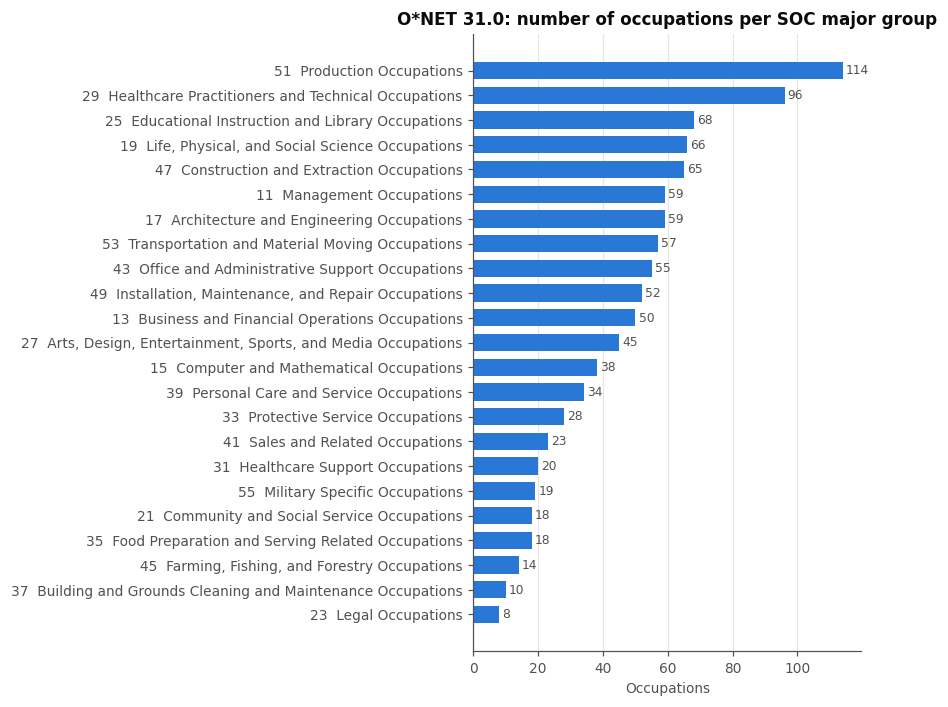

In [9]:
grp = occ.groupby(['major', 'major_name']).size().reset_index(name='n_occupations').sort_values('n_occupations')
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(grp['major'] + '  ' + grp['major_name'], grp['n_occupations'], color=BLUE, height=0.7)
ax.set_title('O*NET 31.0: number of occupations per SOC major group')
ax.set_xlabel('Occupations'); ax.grid(axis='y', visible=False)
for i, v in enumerate(grp['n_occupations']):
    ax.text(v + 1, i, str(v), va='center', color=TEXT2, fontsize=8)
plt.tight_layout(); plt.show()

**Observation:** Production, Healthcare Practitioners and Management have the most occupations. When we link to the GSS we need to check whether GSS respondents are also spread across these major groups; some groups may end up with too few people for subgroup analysis (the advisors' hypothesis is precisely that satisfaction drivers differ by occupation category).

## 4. Work Values (30.2, legacy content model 1.B.2)

This is the core table for person-job fit. O*NET Work Values are based on the **Theory of Work Adjustment**. Six dimensions describe which kinds of needs an occupation can satisfy:

| Element ID | Dimension | Meaning |
|---|---|---|
| 1.B.2.a | Achievement | Using one's abilities, seeing results |
| 1.B.2.b | Working Conditions | Stability, activity, compensation, independence in the environment |
| 1.B.2.c | Recognition | Advancement, status, authority |
| 1.B.2.d | Relationships | Co-workers, service to others, moral values |
| 1.B.2.e | Support | Management support, company policies |
| 1.B.2.f | Independence | Autonomy, creativity, responsibility |

Each dimension is rated on **EX (Extent) 1-7**. There are also three VH rows (Work Value High-Point): the codes of the occupation's top three dimensions.

In [10]:
wv = pd.read_csv(V302 / 'Work Values.txt', sep='\t')
print(wv.shape, wv.columns.tolist())
display(wv.head(9))
print('Rows per Element x Scale:')
display(wv.groupby(['Element ID','Element Name','Scale ID']).size().rename('rows').reset_index())

(7866, 7) ['O*NET-SOC Code', 'Element ID', 'Element Name', 'Scale ID', 'Data Value', 'Date', 'Domain Source']


,O*NET-SOC Code,Element ID,Element Name,Scale ID,Data Value,Date,Domain Source
0,11-1011.00,1.B.2.a,Achievement,EX,6.33,06/2008,Analyst
1,11-1011.00,1.B.2.b,Working Conditions,EX,6.33,06/2008,Analyst
2,11-1011.00,1.B.2.c,Recognition,EX,7.00,06/2008,Analyst
3,11-1011.00,1.B.2.d,Relationships,EX,5.00,06/2008,Analyst
4,11-1011.00,1.B.2.e,Support,EX,5.33,06/2008,Analyst
5,11-1011.00,1.B.2.f,Independence,EX,7.00,06/2008,Analyst
6,11-1011.00,1.B.2.g,First Work Value High-Point,VH,3.00,06/2008,Analyst
7,11-1011.00,1.B.2.h,Second Work Value High-Point,VH,6.00,06/2008,Analyst
8,11-1011.00,1.B.2.i,Third Work Value High-Point,VH,1.00,06/2008,Analyst


Rows per Element x Scale:


,Element ID,Element Name,Scale ID,rows
0,1.B.2.a,Achievement,EX,874
1,1.B.2.b,Working Conditions,EX,874
2,1.B.2.c,Recognition,EX,874
3,1.B.2.d,Relationships,EX,874
4,1.B.2.e,Support,EX,874
5,1.B.2.f,Independence,EX,874
6,1.B.2.g,First Work Value High-Point,VH,874
7,1.B.2.h,Second Work Value High-Point,VH,874
8,1.B.2.i,Third Work Value High-Point,VH,874


In [11]:
# How recent is the data, and who rated it?
print('Date distribution:'); display(wv['Date'].value_counts().rename('rows').to_frame().T)
print('Domain Source distribution:'); display(wv['Domain Source'].value_counts().rename('rows').to_frame().T)

Date distribution:


Date,06/2008,06/2009,07/2012,11/2020
rows,6057,684,648,477


Domain Source distribution:


Domain Source,Analyst,Analyst - Transition
rows,7389,477


**Important caveat:** The large majority of Work Values ratings were made by analysts in **2008**; only new occupations were added in 2009 / 2012 / 2020, and the table was never refreshed as a whole. So this table reflects judgments about occupations made almost 20 years ago. This belongs in the "data limitations" section.

In [12]:
# Wide format: one row per occupation, 6 Work Values columns
WV_ORDER = ['Achievement','Working Conditions','Recognition','Relationships','Support','Independence']
wv_wide = (wv[wv['Scale ID']=='EX']
           .pivot(index='O*NET-SOC Code', columns='Element Name', values='Data Value')[WV_ORDER])
print('Occupations with Work Values:', len(wv_wide))
display(wv_wide.describe().round(2))

Occupations with Work Values: 874


Element Name,Achievement,Working Conditions,Recognition,Relationships,Support,Independence
count,874.00,874.00,874.00,874.00,874.00,874.00
mean,4.12,4.08,3.64,4.45,4.38,4.37
std,1.40,1.13,1.31,1.14,0.95,1.19
min,1.00,1.50,1.00,1.67,1.67,1.67
25%,3.00,3.17,2.33,3.67,3.67,3.33
50%,4.33,4.17,3.67,4.33,4.33,4.67
75%,5.33,5.00,4.67,5.33,5.00,5.33
max,7.00,6.50,7.00,7.00,7.00,7.00


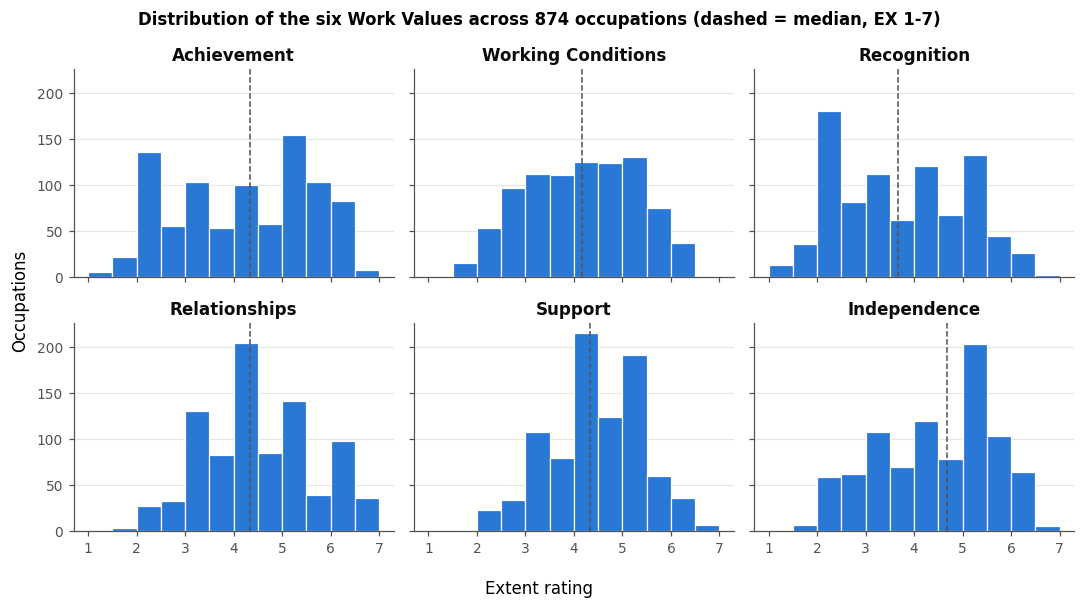

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5.5), sharex=True, sharey=True)
for ax, col in zip(axes.flat, WV_ORDER):
    ax.hist(wv_wide[col], bins=np.arange(1, 7.5, 0.5), color=BLUE, edgecolor='white', linewidth=0.8)
    ax.set_title(col); ax.axvline(wv_wide[col].median(), color=TEXT2, lw=1, ls='--')
    ax.grid(axis='x', visible=False)
fig.suptitle('Distribution of the six Work Values across 874 occupations (dashed = median, EX 1-7)', fontweight='bold')
fig.supxlabel('Extent rating'); fig.supylabel('Occupations')
plt.tight_layout(); plt.show()

**Observations:**
- Recognition is lowest overall and most dispersed (many occupations offer "little advancement or status"); Support is the most concentrated.
- None of the six is normal, and the scale only runs 1-7. Fit scoring will need standardization (z-scores or within-dimension percentiles).

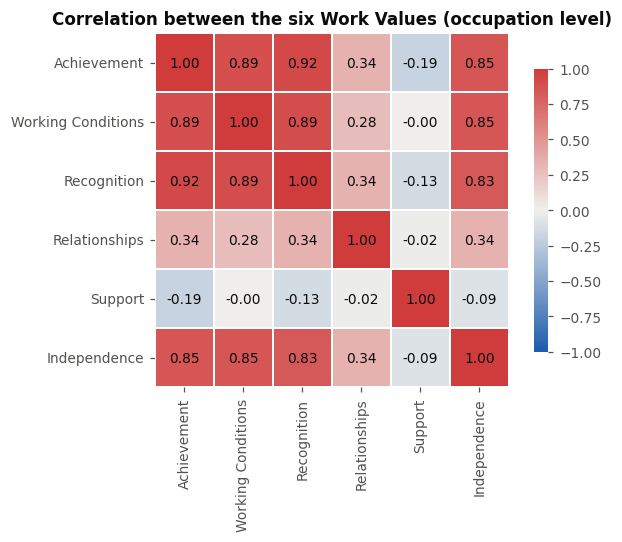

In [14]:
corr = wv_wide.corr()
fig, ax = plt.subplots(figsize=(6.2, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=DIV, vmin=-1, vmax=1, center=0, square=True,
            linewidths=1, linecolor='white', cbar_kws={'shrink': 0.8}, ax=ax,
            annot_kws={'size': 9, 'color': TEXT})
ax.set_title('Correlation between the six Work Values (occupation level)')
ax.set_xlabel(''); ax.set_ylabel(''); ax.grid(False)
plt.tight_layout(); plt.show()

**Observation:** Achievement, Working Conditions, Recognition and Independence are highly inter-correlated (roughly "high-skill, high-status" occupations); Support and Relationships are relatively independent. In practice the six dimensions may carry only 2-3 factors of information, so simply summing six per-dimension fit scores would double-count.

In [15]:
# Top / bottom 5 occupations on each dimension
wv_named = wv_wide.join(occ.set_index('O*NET-SOC Code')['Title'])
for col in WV_ORDER:
    top = wv_named.nlargest(5, col)[['Title', col]]
    bot = wv_named.nsmallest(5, col)[['Title', col]]
    print(f'\n=== {col} ===')
    print('  highest:', ' | '.join(f"{t} ({v:.2f})" for t, v in zip(top['Title'], top[col])))
    print('  lowest: ', ' | '.join(f"{t} ({v:.2f})" for t, v in zip(bot['Title'], bot[col])))


=== Achievement ===
  highest: Veterinarians (7.00) | Chief Sustainability Officers (6.67) | Biofuels/Biodiesel Technology and Product Development Managers (6.67) | Fundraisers (6.67) | Nanosystems Engineers (6.67)
  lowest:  Graders and Sorters, Agricultural Products (1.00) | Ushers, Lobby Attendants, and Ticket Takers (1.33) | Locker Room, Coatroom, and Dressing Room Attendants (1.33) | Helpers--Production Workers (1.33) | Cleaners of Vehicles and Equipment (1.33)

=== Working Conditions ===
  highest: Computer and Information Systems Managers (6.50) | Chief Executives (6.33) | Chief Sustainability Officers (6.33) | Judges, Magistrate Judges, and Magistrates (6.33) | Marketing Managers (6.17)
  lowest:  Cooks, Fast Food (1.50) | Dishwashers (1.50) | Slaughterers and Meat Packers (1.50) | Pressers, Textile, Garment, and Related Materials (1.50) | Dining Room and Cafeteria Attendants and Bartender Helpers (1.67)

=== Recognition ===
  highest: Chief Executives (7.00) | Pediatricians, 

In [16]:
# High-Point coding: VH values 1-6 map to the six dimensions in Element ID order a-f
VH_MAP = {1:'Achievement', 2:'Working Conditions', 3:'Recognition', 4:'Relationships', 5:'Support', 6:'Independence'}
hp = (wv[wv['Scale ID']=='VH']
      .pivot(index='O*NET-SOC Code', columns='Element Name', values='Data Value')
      .rename(columns={'First Work Value High-Point':'hp1','Second Work Value High-Point':'hp2','Third Work Value High-Point':'hp3'}))
for c in ['hp1','hp2','hp3']:
    hp[c] = hp[c].map(VH_MAP)
# Check: does hp1 equal the argmax of the six EX ratings?
check = (hp['hp1'] == wv_wide.idxmax(axis=1))
ties = wv_wide.eq(wv_wide.max(axis=1), axis=0).sum(axis=1) > 1
print('Share where hp1 == argmax(EX):', round(check.mean(), 3), '| of the', (~check).sum(), 'mismatches,', ties[~check].sum(), 'are tied maxima')
print('\nOccupations per dimension as first High-Point:')
display(hp['hp1'].value_counts().rename('n_occupations').to_frame().T)

Share where hp1 == argmax(EX): 0.922 | of the 68 mismatches, 68 are tied maxima

Occupations per dimension as first High-Point:


hp1,Support,Relationships,Achievement,Independence,Working Conditions,Recognition
n_occupations,280,246,165,130,37,16


**Observation:** Every mismatch between hp1 and the EX argmax is a tie (idxmax just takes the first). The High-Point data is internally consistent. If we later use High-Point as the occupation's "dominant value", we need a rule for ties.

In [17]:
# Coverage: which occupations lack Work Values?
occ['has_wv'] = occ['O*NET-SOC Code'].isin(wv_wide.index)
print('Occupations without Work Values:', (~occ['has_wv']).sum())
print('\nSplit by SOC base vs O*NET specialty:')
display(pd.crosstab(occ['is_base'].map({True:'SOC base (.00)', False:'O*NET specialty (.xx)'}), occ['has_wv'].map({True:'has WV', False:'no WV'})))
print('\nOccupations without Work Values, by major group:')
display(occ[~occ['has_wv']].groupby('major_name').size().sort_values(ascending=False).rename('missing').to_frame().T)

Occupations without Work Values: 142

Split by SOC base vs O*NET specialty:


has_wv,has WV,no WV
is_base,,
O*NET specialty (.xx),139,10
SOC base (.00),735,132



Occupations without Work Values, by major group:


major_name,Military Specific Occupations,Healthcare Practitioners and Technical Occupations,Educational Instruction and Library Occupations,Transportation and Material Moving Occupations,"Life, Physical, and Social Science Occupations",Computer and Mathematical Occupations,Management Occupations,Business and Financial Operations Occupations,Production Occupations,"Arts, Design, Entertainment, Sports, and Media Occupations",Personal Care and Service Occupations,Protective Service Occupations,Office and Administrative Support Occupations,Architecture and Engineering Occupations,Construction and Extraction Occupations,Community and Social Service Occupations,"Installation, Maintenance, and Repair Occupations",Food Preparation and Serving Related Occupations,"Farming, Fishing, and Forestry Occupations",Building and Grounds Cleaning and Maintenance Occupations,Sales and Related Occupations,Legal Occupations,Healthcare Support Occupations
missing,19,18,11,10,9,9,8,7,7,7,5,4,4,4,4,4,2,2,2,2,2,1,1


**Observation:** Of the 142 occupations without Work Values, **132 are SOC base occupations (.00)**; only 10 are specialties, and Military Specific accounts for 19. Section 6 checks availability after aggregation to SOC.

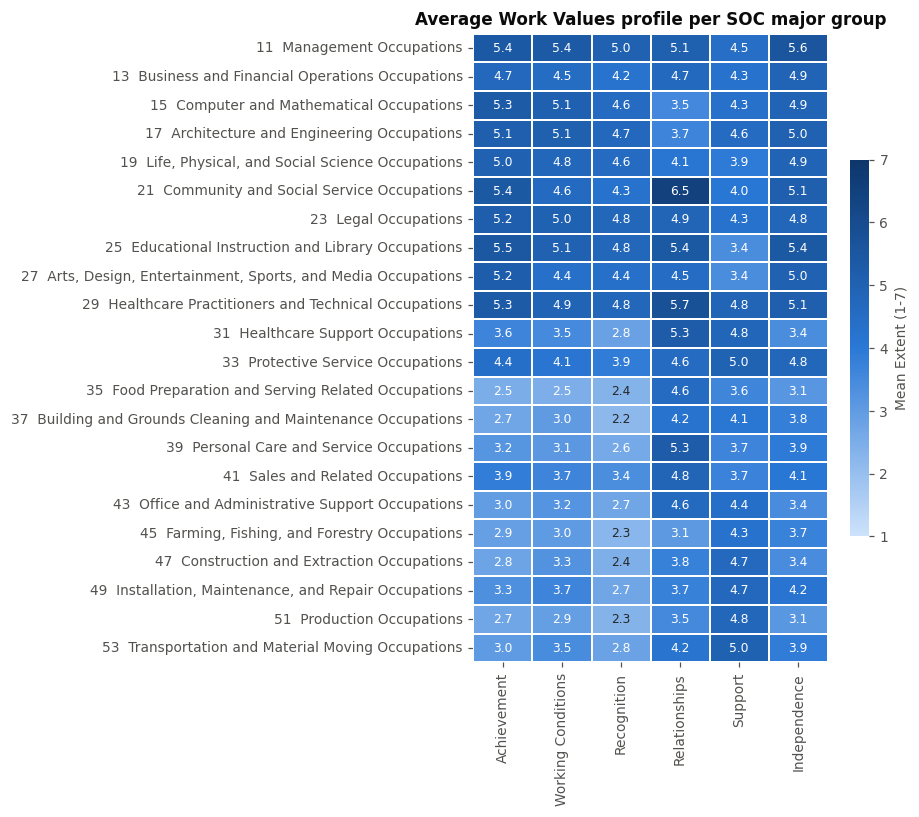

In [18]:
# Average Work Values profile per major group
wv_major = (wv_wide.join(occ.set_index('O*NET-SOC Code')[['major','major_name']])
            .groupby(['major','major_name'])[WV_ORDER].mean())
wv_major.index = [f'{m}  {n}' for m, n in wv_major.index]
fig, ax = plt.subplots(figsize=(8.5, 7.5))
sns.heatmap(wv_major, annot=True, fmt='.1f', cmap=SEQ, vmin=1, vmax=7, linewidths=1, linecolor='white',
            cbar_kws={'shrink': 0.6, 'label': 'Mean Extent (1-7)'}, ax=ax, annot_kws={'size': 8})
ax.set_title('Average Work Values profile per SOC major group'); ax.set_ylabel(''); ax.grid(False)
plt.tight_layout(); plt.show()

**Observation:** Management, Legal and Healthcare Practitioners are high on Achievement / Recognition / Independence across the board; Food Prep, Building & Grounds and Production are low across the board. This is essentially an "occupational status" axis. If the fit feature is simply "personal values x occupation Work Values", it may be highly collinear with baseline variables such as income and education. That is exactly the risk for Track A (how much fit adds beyond the baseline).

## 5. Other candidate dimensions in 31.0

Essential Skills describe occupational requirements. Work Context describes physical and social conditions of work. Both can become occupation-level predictors after linkage to a survey. Neither measures a respondent's own skills or preferences.

### 5.1 Essential Skills

This section checks the row structure, coverage, scales, rating sources, quality flags, and variation across occupations before constructing wide tables.

Sources: [Essential Skills dictionary](https://www.onetcenter.org/dictionary/31.0/csv/essential_skills.html), [Scales Reference](https://www.onetcenter.org/dictionary/31.0/csv/scales_reference.html), and [scale definitions](https://www.onetonline.org/help/online/scales).

In [19]:
skills = pd.read_csv(V31 / 'essential_skills.csv')
print('Rows and columns:', skills.shape)
display(skills.head())

Rows and columns: (18200, 15)


,O*NET-SOC Code,Title,Element ID,Element Name,Scale ID,Scale Name,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source
0,11-1011.00,Chief Executives,2.A.1.a,Reading Comprehension,IM,Importance,4.12,8,0.1250,3.8800,4.3700,N,NaN,08/2023,Analyst
1,11-1011.00,Chief Executives,2.A.1.a,Reading Comprehension,LV,Level,4.62,8,0.1830,4.2664,4.9836,N,N,08/2023,Analyst
2,11-1011.00,Chief Executives,2.A.1.b,Active Listening,IM,Importance,4.00,8,0.0000,4.0000,4.0000,N,NaN,08/2023,Analyst
3,11-1011.00,Chief Executives,2.A.1.b,Active Listening,LV,Level,4.75,8,0.1637,4.4292,5.0708,N,N,08/2023,Analyst
4,11-1011.00,Chief Executives,2.A.1.c,Writing,IM,Importance,4.12,8,0.1250,3.8800,4.3700,N,NaN,08/2023,Analyst


**Observation:** Each occupation-skill pair has separate Importance (IM) and Level (LV) ratings. A row is a rating, not a list of skills possessed by a worker.

In [20]:
skill_key = ['O*NET-SOC Code', 'Element ID', 'Scale ID']
print('Duplicate rating keys:', skills.duplicated(skill_key).sum())
assert not skills.duplicated(skill_key).any()
display(skills.groupby('Scale ID').agg(
    rows=('Data Value', 'size'),
    occupations=('O*NET-SOC Code', 'nunique'),
    skills=('Element ID', 'nunique'),
))
display(skills.groupby(['O*NET-SOC Code', 'Scale ID'])['Element ID']
        .nunique().value_counts().rename('occupation-scale pairs').to_frame())
skill_coverage = occ.assign(has_skills=occ['O*NET-SOC Code'].isin(skills['O*NET-SOC Code']))
display(skill_coverage.groupby('is_base')['has_skills'].agg(['size', 'sum']))
print('Catalog occupations without skills:', (~skill_coverage['has_skills']).sum())

Duplicate rating keys: 0


,rows,occupations,skills
Scale ID,,,
IM,9100,910,10
LV,9100,910,10


,occupation-scale pairs
Element ID,
10,1820


,size,sum
is_base,,
False,149,149
True,867,761


Catalog occupations without skills: 106


**Observation:** All 910 covered occupations have the same 10 skills under both scales. The occupation catalog contains another 106 codes without this table. Record presence cannot distinguish the covered occupations.

In [21]:
# Scale bounds and Level examples come from the published reference files.
scales = pd.read_csv(V31 / 'scales_reference.csv')
display(scales.head())
anchors = pd.read_csv(V31 / 'level_scale_anchors.csv')
display(anchors.head())
display(scales[scales['Scale ID'].isin(skills['Scale ID'])])
skill_elements = skills[['Element ID', 'Element Name']].drop_duplicates()
display(skill_elements)
example_skill_id = skill_elements['Element ID'].iloc[0]
display(anchors[anchors['Element ID'].eq(example_skill_id)])

,Scale ID,Scale Name,Minimum,Maximum
0,AO,Automation,1,5
1,CF,Frequency,1,5
2,CN,Amount of Contact,1,5
3,CT,Context,1,3
4,CTP,Context (Categories 1-3),0,100


,Element ID,Element Name,Scale ID,Scale Name,Anchor Value,Anchor Description
0,1.A.1.a.1,Oral Comprehension,LV,Level,2,Understand a television commercial
1,1.A.1.a.1,Oral Comprehension,LV,Level,4,Understand a coach's oral instructions for a sport
2,1.A.1.a.1,Oral Comprehension,LV,Level,6,Understand a lecture on advanced physics
3,1.A.1.a.2,Written Comprehension,LV,Level,2,Understand signs on the highway
4,1.A.1.a.2,Written Comprehension,LV,Level,4,Understand an apartment lease


,Scale ID,Scale Name,Minimum,Maximum
15,IM,Importance,1,5
18,LV,Level,0,7


,Element ID,Element Name
0,2.A.1.a,Reading Comprehension
2,2.A.1.b,Active Listening
4,2.A.1.c,Writing
6,2.A.1.d,Speaking
8,2.A.1.e,Mathematics
10,2.A.1.f,Science
12,2.A.2.a,Critical Thinking
14,2.A.2.b,Active Learning
16,2.A.2.c,Learning Strategies
18,2.A.2.d,Monitoring


,Element ID,Element Name,Scale ID,Scale Name,Anchor Value,Anchor Description
156,2.A.1.a,Reading Comprehension,LV,Level,2,Read step-by-step instructions for completing a form
157,2.A.1.a,Reading Comprehension,LV,Level,4,Understand an email from management describing new perso...
158,2.A.1.a,Reading Comprehension,LV,Level,6,Read a scientific journal article describing surgical pr...


**Observation:** IM ranges from 1 to 5 and describes importance to job performance. LV ranges from 0 to 7 and describes the amount of skill required. Level anchors are specific to each skill, so equal numerical ratings across skills need their own interpretation. The reference files are documented at [Level Scale Anchors](https://www.onetcenter.org/dictionary/31.0/csv/level_scale_anchors.html).

In [22]:
skill_dates = skills.assign(rating_date=pd.to_datetime(skills['Date'], format='%m/%Y'))
display(skill_dates.groupby('Domain Source').agg(
    rows=('Data Value', 'size'),
    occupations=('O*NET-SOC Code', 'nunique'),
    earliest=('rating_date', 'min'),
    latest=('rating_date', 'max'),
))
display(skill_dates.groupby('rating_date')['O*NET-SOC Code'].nunique()
        .rename('occupations with ratings at this date').to_frame())
display(skills.groupby('Scale ID').agg(
    suppress_Y=('Recommend Suppress', lambda x: x.eq('Y').sum()),
    suppress_missing=('Recommend Suppress', lambda x: x.isna().sum()),
    not_relevant_Y=('Not Relevant', lambda x: x.eq('Y').sum()),
    not_relevant_missing=('Not Relevant', lambda x: x.isna().sum()),
    missing_values=('Data Value', lambda x: x.isna().sum()),
))
display(skills.loc[skills['Not Relevant'].eq('Y'), 'Data Value'].describe())

,rows,occupations,earliest,latest
Domain Source,,,,
Analyst,18200,910,2010-06-01,2026-08-01


,occupations with ratings at this date
rating_date,
2010-06-01,16
2011-07-01,3
2012-07-01,6
2013-07-01,10
2014-07-01,20
2015-07-01,30
2016-07-01,42
2017-07-01,44
2018-08-01,46


,suppress_Y,suppress_missing,not_relevant_Y,not_relevant_missing,missing_values
Scale ID,,,,,
IM,0,0,0,9100,0
LV,21,0,298,0,0


count    298.000000
mean       0.104933
std        0.147146
min        0.000000
25%        0.000000
50%        0.000000
75%        0.250000
max        0.750000
Name: Data Value, dtype: float64

**Observation:** These are analyst ratings dated from June 2010 to August 2026. There are 21 LV ratings marked for suppression and 298 marked Not Relevant. Not Relevant values range from 0 to 0.75, so this flag is not equivalent to a recorded zero. The flag is absent on IM rows.

The official [analyst rating statistics](https://www.onetcenter.org/dictionary/31.0/csv/appendix_analyst.html) distinguish low precision from lack of relevance. Raw ratings and their flags are retained below. For an exploratory analysis view, explicitly suppressed ratings are masked; LV ratings marked Not Relevant are also masked. This is a documented view for inspection, not a finalized modeling policy.

In [23]:
skill_presence = pd.crosstab(skills['O*NET-SOC Code'], skills['Element Name']).gt(0).astype(int)
display(pd.DataFrame({
    'occupations_with_record': skill_presence.sum(),
    'distinct_presence_values': skill_presence.nunique(),
}))
print('Distinct presence profiles:', len(skill_presence.drop_duplicates()))

skill_order = skill_elements['Element Name'].tolist()
skill_im_raw = skills.loc[skills['Scale ID'].eq('IM')].pivot(
    index='O*NET-SOC Code', columns='Element Name', values='Data Value'
).reindex(columns=skill_order)
skill_lv_raw = skills.loc[skills['Scale ID'].eq('LV')].pivot(
    index='O*NET-SOC Code', columns='Element Name', values='Data Value'
).reindex(columns=skill_order)
skill_analysis = skills.copy()
skill_mask = skill_analysis['Recommend Suppress'].eq('Y') | (
    skill_analysis['Scale ID'].eq('LV') & skill_analysis['Not Relevant'].eq('Y')
)
skill_analysis['Data Value'] = skill_analysis['Data Value'].mask(skill_mask)
skill_im = skill_analysis.loc[skill_analysis['Scale ID'].eq('IM')].pivot(
    index='O*NET-SOC Code', columns='Element Name', values='Data Value'
).reindex(index=occ['O*NET-SOC Code'], columns=skill_order)
skill_lv = skill_analysis.loc[skill_analysis['Scale ID'].eq('LV')].pivot(
    index='O*NET-SOC Code', columns='Element Name', values='Data Value'
).reindex(index=occ['O*NET-SOC Code'], columns=skill_order)
print('Catalog-aligned IM / LV shapes:', skill_im.shape, skill_lv.shape)
print('Masked rating rows:', int(skill_mask.sum()))
display(skill_im.join(occ.set_index('O*NET-SOC Code')['Title']).head())
display(pd.DataFrame({
    'IM_valid_occupations': skill_im.count(),
    'LV_valid_occupations': skill_lv.count(),
    'IM_unique_ratings': skill_im.nunique(),
    'IM_std': skill_im.std(),
    'LV_std': skill_lv.std(),
}).round(3))

,occupations_with_record,distinct_presence_values
Element Name,,
Active Learning,910,1
Active Listening,910,1
Critical Thinking,910,1
Learning Strategies,910,1
Mathematics,910,1
Monitoring,910,1
Reading Comprehension,910,1
Science,910,1
Speaking,910,1


Distinct presence profiles: 1
Catalog-aligned IM / LV shapes: (1016, 10) (1016, 10)
Masked rating rows: 318


,Reading Comprehension,Active Listening,Writing,Speaking,Mathematics,Science,Critical Thinking,Active Learning,Learning Strategies,Monitoring,Title
O*NET-SOC Code,,,,,,,,,,,
11-1011.00,4.12,4.00,4.12,4.25,3.25,1.62,4.38,3.75,3.12,4.00,Chief Executives
11-1011.03,4.00,4.00,4.12,4.00,2.88,2.12,4.12,3.75,3.38,3.75,Chief Sustainability Officers
11-1021.00,4.00,4.00,3.50,4.00,2.62,1.50,3.88,3.62,3.00,4.00,General and Operations Managers
11-1031.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Legislators
11-2011.00,3.75,4.12,3.75,4.12,2.88,1.50,3.88,3.38,3.00,3.50,Advertising and Promotions Managers


,IM_valid_occupations,LV_valid_occupations,IM_unique_ratings,IM_std,LV_std
Element Name,,,,,
Reading Comprehension,910,910,25,0.564,0.851
Active Listening,910,910,22,0.470,0.645
Writing,910,910,26,0.647,0.858
Speaking,910,910,22,0.498,0.718
Mathematics,910,906,32,0.597,0.890
Science,910,597,30,0.896,1.313
Critical Thinking,910,910,21,0.468,0.654
Active Learning,910,910,21,0.545,0.790
Learning Strategies,910,909,28,0.581,0.774


**Observation:** Presence coding produces one identical profile for all 910 covered occupations. The continuous ratings vary across occupations. Catalog alignment preserves the 106 uncovered codes as missing rather than coding them as zero. The analysis view masks 318 distinct LV rows because one row carries both quality flags.

,IM >= 2 (%),IM >= 3 (%),IM >= 4 (%)
Element Name,,,
Reading Comprehension,99.9,81.2,31.0
Active Listening,100.0,92.2,32.3
Writing,98.5,65.2,16.2
Speaking,100.0,89.1,29.6
Mathematics,91.5,26.0,2.5
Science,36.4,16.6,4.0
Critical Thinking,100.0,88.9,23.5
Active Learning,99.3,64.6,6.5
Learning Strategies,97.1,40.2,5.5


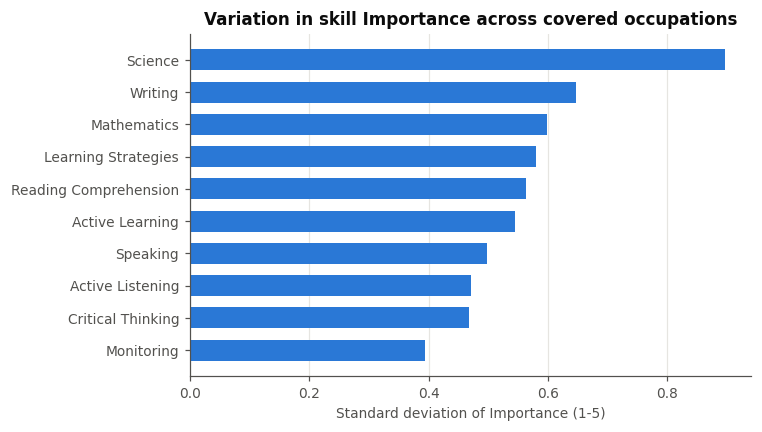

In [24]:
# These cutoffs illustrate information loss; none is selected for modeling.
cutoffs = [2.0, 3.0, 4.0]
skill_threshold_rates = pd.DataFrame({
    f'IM >= {cutoff:g} (%)': skill_im.ge(cutoff).sum().div(skill_im.count()).mul(100)
    for cutoff in cutoffs
})
display(skill_threshold_rates.round(1))
dispersion = skill_im.std().sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(dispersion.index, dispersion.values, color=BLUE, height=0.65)
ax.set_title('Variation in skill Importance across covered occupations')
ax.set_xlabel('Standard deviation of Importance (1-5)')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

**Observation:** Threshold-based indicators depend on the cutoff and discard differences within each side of it. The percentages use valid covered occupations as their denominator; uncovered occupations are excluded. These are occupation-level proportions, not population-weighted proportions of workers.

Essential Skills measure occupational demands. Constructing skill fit would additionally require a compatible measure of the individual's skills. An occupation's Writing rating alone is not evidence that a particular respondent has that writing ability.

### 5.2 Work Context

This section checks what one row represents, occupation coverage, scale meanings, rating sources and dates, and whether each item describes a requirement or an opportunity at work.

Sources: [Work Context dictionary](https://www.onetcenter.org/dictionary/31.0/csv/work_context.html), [Work Context Categories](https://www.onetcenter.org/dictionary/31.0/csv/work_context_categories.html), and [rating statistics](https://www.onetcenter.org/dictionary/31.0/csv/appendix_incumbent.html).

In [25]:
wc = pd.read_csv(V31 / 'work_context.csv')
print('Rows and columns:', wc.shape)
display(wc.head())

Rows and columns: (305389, 16)


,O*NET-SOC Code,Title,Element ID,Element Name,Scale ID,Scale Name,Category,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source
0,11-1011.00,Chief Executives,4.C.1.a.2.c,Public Speaking,CX,Context,NaN,3.07,37.0,0.2851,2.4923,3.6486,N,NaN,08/2023,Incumbent
1,11-1011.00,Chief Executives,4.C.1.a.2.c,Public Speaking,CXP,Context (Categories 1-5),1.0,0.13,37.0,0.1370,0.0160,1.0770,N,NaN,08/2023,Incumbent
2,11-1011.00,Chief Executives,4.C.1.a.2.c,Public Speaking,CXP,Context (Categories 1-5),2.0,39.49,37.0,11.0101,20.4073,62.4299,N,NaN,08/2023,Incumbent
3,11-1011.00,Chief Executives,4.C.1.a.2.c,Public Speaking,CXP,Context (Categories 1-5),3.0,33.07,37.0,7.1359,20.4456,48.7245,N,NaN,08/2023,Incumbent
4,11-1011.00,Chief Executives,4.C.1.a.2.c,Public Speaking,CXP,Context (Categories 1-5),4.0,7.79,37.0,4.3613,2.4093,22.4457,N,NaN,08/2023,Incumbent


**Observation:** Mean ratings and category percentages are stored as separate rows. Category is empty for a mean and populated for a percentage. A single occupation-item pair therefore contributes several rows.

In [26]:
wc_key = ['O*NET-SOC Code', 'Element ID', 'Scale ID', 'Category']
print('Duplicate rating keys:', wc.duplicated(wc_key).sum())
assert not wc.duplicated(wc_key).any()
display(wc.groupby('Scale ID').agg(
    rows=('Data Value', 'size'),
    occupations=('O*NET-SOC Code', 'nunique'),
    items=('Element ID', 'nunique'),
    observed_min=('Data Value', 'min'),
    observed_max=('Data Value', 'max'),
).join(scales.set_index('Scale ID')[['Scale Name', 'Minimum', 'Maximum']]))
display(wc.groupby('O*NET-SOC Code')['Element ID'].nunique()
        .value_counts().rename('occupations').to_frame())
print('Catalog occupations without Work Context:',
      (~occ['O*NET-SOC Code'].isin(wc['O*NET-SOC Code'])).sum())

Duplicate rating keys: 0


,rows,occupations,items,observed_min,observed_max,Scale Name,Minimum,Maximum
Scale ID,,,,,,,,
CT,1822,911,2,1.0,3.0,Context,1,3
CTP,5412,902,2,0.0,100.0,Context (Categories 1-3),0,100
CX,50105,911,55,1.0,5.0,Context,1,5
CXP,248050,902,55,0.0,100.0,Context (Categories 1-5),0,100


,occupations
Element ID,
57,911


Catalog occupations without Work Context: 105


**Observation:** All 911 covered occupations have 57 mean ratings. CX contains 55 items on a 1-5 scale; CT contains two on a 1-3 scale. CXP and CTP hold percentages on a 0-100 scale and cover 902 occupations. The remaining nine have mean ratings without category distributions.

In [27]:
wc_categories = pd.read_csv(V31 / 'work_context_categories.csv')
display(wc_categories.head())
ct_elements = wc.loc[wc['Scale ID'].eq('CT'), ['Element ID', 'Element Name']].drop_duplicates()
display(wc_categories[wc_categories['Element ID'].isin(ct_elements['Element ID'])])
context_example_ids = wc.loc[
    wc['Element Name'].isin(['Freedom to Make Decisions', 'Time Pressure']), 'Element ID'
].unique()
display(wc_categories[wc_categories['Element ID'].isin(context_example_ids)])

,Element ID,Element Name,Scale ID,Scale Name,Category,Category Description
0,4.C.1.a.2.c,Public Speaking,CXP,Context (Categories 1-5),1,Never
1,4.C.1.a.2.c,Public Speaking,CXP,Context (Categories 1-5),2,Once a year or more but not every month
2,4.C.1.a.2.c,Public Speaking,CXP,Context (Categories 1-5),3,Once a month or more but not every week
3,4.C.1.a.2.c,Public Speaking,CXP,Context (Categories 1-5),4,Once a week or more but not every day
4,4.C.1.a.2.c,Public Speaking,CXP,Context (Categories 1-5),5,Every day


,Element ID,Element Name,Scale ID,Scale Name,Category,Category Description
275,4.C.3.d.4,Work Schedules,CTP,Context (Categories 1-3),1,"Regular (established routine, set schedule)"
276,4.C.3.d.4,Work Schedules,CTP,Context (Categories 1-3),2,"Irregular (changes with weather conditions, production d..."
277,4.C.3.d.4,Work Schedules,CTP,Context (Categories 1-3),3,Seasonal (only during certain times of the year)
278,4.C.3.d.8,Duration of Typical Work Week,CTP,Context (Categories 1-3),1,Less than 40 hours
279,4.C.3.d.8,Duration of Typical Work Week,CTP,Context (Categories 1-3),2,40 hours
280,4.C.3.d.8,Duration of Typical Work Week,CTP,Context (Categories 1-3),3,More than 40 hours


,Element ID,Element Name,Scale ID,Scale Name,Category,Category Description
235,4.C.3.a.4,Freedom to Make Decisions,CXP,Context (Categories 1-5),1,No freedom
236,4.C.3.a.4,Freedom to Make Decisions,CXP,Context (Categories 1-5),2,Very little freedom
237,4.C.3.a.4,Freedom to Make Decisions,CXP,Context (Categories 1-5),3,Limited freedom
238,4.C.3.a.4,Freedom to Make Decisions,CXP,Context (Categories 1-5),4,Some freedom
239,4.C.3.a.4,Freedom to Make Decisions,CXP,Context (Categories 1-5),5,A lot of freedom
265,4.C.3.d.1,Time Pressure,CXP,Context (Categories 1-5),1,Never
266,4.C.3.d.1,Time Pressure,CXP,Context (Categories 1-5),2,Once a year or more but not every month
267,4.C.3.d.1,Time Pressure,CXP,Context (Categories 1-5),3,Once a month or more but not every week
268,4.C.3.d.1,Time Pressure,CXP,Context (Categories 1-5),4,Once a week or more but not every day
269,4.C.3.d.1,Time Pressure,CXP,Context (Categories 1-5),5,Every day


**Observation:** Higher scores do not have one common meaning. Freedom to Make Decisions runs from less to more freedom; Time Pressure runs from less to more frequent pressure. Work Schedules distinguishes regular, irregular and seasonal arrangements, which are not ordered from worse to better. Duration of Typical Work Week uses hours categories rather than exact hours. A sum over these items would mix different concepts.

In [28]:
wc_means = wc.loc[wc['Scale ID'].isin(['CX', 'CT'])].copy()
wc_means['rating_date'] = pd.to_datetime(wc_means['Date'], format='%m/%Y')
display(wc_means.groupby('Domain Source').agg(
    mean_rows=('Data Value', 'size'),
    occupations=('O*NET-SOC Code', 'nunique'),
    earliest=('rating_date', 'min'),
    latest=('rating_date', 'max'),
))
wc_quality = wc.groupby(['Scale ID', 'Domain Source']).agg(
    rows=('Data Value', 'size'),
    suppress_Y=('Recommend Suppress', lambda x: x.eq('Y').sum()),
    suppress_missing=('Recommend Suppress', lambda x: x.isna().sum()),
    N_missing=('N', lambda x: x.isna().sum()),
    CI_missing=('Lower CI Bound', lambda x: x.isna().sum()),
)
display(wc_quality)
display(wc_means.groupby('Domain Source')['N'].agg(['count', 'min', 'median', 'max']))

,mean_rows,occupations,earliest,latest
Domain Source,,,,
Analyst - Transition,513,9,2020-11-01,2020-11-01
Incumbent,37278,654,2005-12-01,2026-08-01
Occupational Expert,14136,248,2006-06-01,2026-08-01


rows  suppress_Y  suppress_missing  N_missing  CI_missing
Scale ID Domain Source                                                                    
CT       Analyst - Transition      18           0                 2         18          18
         Incumbent               1308           6                 0          0          42
         Occupational Expert      496           0               496          0         496
CTP      Incumbent               3924         335                 0          0         682
         Occupational Expert     1488           0              1488          0        1488
CX       Analyst - Transition     495           0                55        495         495
         Incumbent              35970         121                 0          0        1587
         Occupational Expert    13640           0             13640          0       13640
CXP      Incumbent             179850       11029                 0          0       40830
         Occupational Expert    68200           0             68200          0       68200

,count,min,median,max
Domain Source,,,,
Analyst - Transition,0,NaN,NaN,NaN
Incumbent,37278,10.0,22.0,99.0
Occupational Expert,14136,13.0,23.0,49.0


**Observation:** Mean ratings span December 2005 to August 2026 and include Incumbent, Occupational Expert and Analyst - Transition sources. A 2026 database release does not make every rating recent. Some rows lack confidence intervals or suppression flags; an absent flag is not evidence that precision was assessed and passed. N describes the O*NET rating sample, not the number of GSS respondents.

In [29]:
wc_percentages = wc.loc[wc['Scale ID'].isin(['CXP', 'CTP'])].copy()
wc_percentages['weighted_category'] = (
    wc_percentages['Category'] * wc_percentages['Data Value'] / 100
)
wc_distribution_check = wc_percentages.groupby(['O*NET-SOC Code', 'Element ID']).agg(
    percentage_sum=('Data Value', 'sum'),
    reconstructed_mean=('weighted_category', 'sum'),
)
reported_mean = wc_means.set_index(['O*NET-SOC Code', 'Element ID'])['Data Value']
wc_distribution_check['reported_mean'] = reported_mean.reindex(wc_distribution_check.index)
wc_distribution_check['absolute_difference'] = (
    wc_distribution_check['reconstructed_mean'] - wc_distribution_check['reported_mean']
).abs()
display(wc_distribution_check[['percentage_sum', 'absolute_difference']].describe().round(5))
# Tolerances allow for rounding in the published two-decimal percentages and means.
assert wc_distribution_check['percentage_sum'].sub(100).abs().le(0.03).all()
assert wc_distribution_check['absolute_difference'].le(0.01).all()
print('Occupation-item distributions checked:', len(wc_distribution_check))

,percentage_sum,absolute_difference
count,51414.00000,51414.00000
mean,100.00006,0.00225
std,0.00531,0.00157
min,99.98000,0.00000
25%,100.00000,0.00080
50%,100.00000,0.00220
75%,100.00000,0.00360
max,100.02000,0.00550


Occupation-item distributions checked: 51414


**Observation:** The 51,414 available distributions sum to 100 within 0.02 percentage points. Their category-weighted means agree with the reported means within 0.0055. This verifies representation consistency, not suitability for a common fit score or absence of sampling error.

In [30]:
wc_cx_raw = wc.loc[wc['Scale ID'].eq('CX')].pivot(
    index='O*NET-SOC Code', columns='Element Name', values='Data Value'
)
wc_ct_raw = wc.loc[wc['Scale ID'].eq('CT')].pivot(
    index='O*NET-SOC Code', columns='Element Name', values='Data Value'
)
wc_analysis = wc_means.copy()
wc_analysis['Data Value'] = wc_analysis['Data Value'].mask(
    wc_analysis['Recommend Suppress'].eq('Y')
)
wc_cx = wc_analysis.loc[wc_analysis['Scale ID'].eq('CX')].pivot(
    index='O*NET-SOC Code', columns='Element Name', values='Data Value'
).reindex(index=occ['O*NET-SOC Code'])
wc_ctp = wc.loc[wc['Scale ID'].eq('CTP')].pivot(
    index='O*NET-SOC Code', columns=['Element ID', 'Category'], values='Data Value'
).reindex(index=occ['O*NET-SOC Code'])
print('Raw CX / CT shapes:', wc_cx_raw.shape, wc_ct_raw.shape)
print('Catalog-aligned CX / CTP shapes:', wc_cx.shape, wc_ctp.shape)
print('Masked CX means:', wc.loc[wc['Scale ID'].eq('CX'), 'Recommend Suppress'].eq('Y').sum())
print('CX occupations with at least one masked mean:',
      wc.loc[wc['Scale ID'].eq('CX')].groupby('O*NET-SOC Code')['Recommend Suppress']
        .apply(lambda x: x.eq('Y').any()).sum())
display(wc_ctp.head())
display(wc_categories.loc[wc_categories['Scale ID'].eq('CTP'),
                          ['Element ID', 'Category', 'Category Description']])

Raw CX / CT shapes: (911, 55) (911, 2)
Catalog-aligned CX / CTP shapes: (1016, 55) (1016, 6)
Masked CX means: 121
CX occupations with at least one masked mean: 32


Element ID     4.C.3.d.4              4.C.3.d.8              
Category             1.0    2.0   3.0       1.0    2.0    3.0
O*NET-SOC Code                                               
11-1011.00         91.58   7.93  0.48       0.0  13.99  86.01
11-1011.03         92.31   7.69  0.00       3.7  18.52  77.78
11-1021.00         84.49  15.51  0.00       0.0  30.08  69.92
11-1031.00           NaN    NaN   NaN       NaN    NaN    NaN
11-2011.00        100.00   0.00  0.00       0.0  19.72  80.28

,Element ID,Category,Category Description
275,4.C.3.d.4,1,"Regular (established routine, set schedule)"
276,4.C.3.d.4,2,"Irregular (changes with weather conditions, production d..."
277,4.C.3.d.4,3,Seasonal (only during certain times of the year)
278,4.C.3.d.8,1,Less than 40 hours
279,4.C.3.d.8,2,40 hours
280,4.C.3.d.8,3,More than 40 hours


**Observation:** The raw CX table is 911 by 55. The exploratory CX view masks 121 explicitly suppressed means across 32 occupations and leaves all 105 uncovered catalog occupations missing. Missing suppression flags remain visible in the quality audit and are not recoded to N. The six CTP columns preserve the two items' category proportions as a separate descriptive view. They remain raw, with their quality flags in the long table; no categorical mean is interpreted as a numeric amount of work conditions.

In [31]:
# These examples illustrate interpretation; they are not a selected modeling feature set.
context_examples = ['Freedom to Make Decisions', 'Time Pressure',
                    'Pace Determined by Speed of Equipment', 'Contact With Others']
display(wc_cx[context_examples].describe().round(2))
context_variation = pd.DataFrame({
    'valid_occupations': wc_cx.count(),
    'unique_ratings': wc_cx.nunique(),
    'mean': wc_cx.mean(),
    'std': wc_cx.std(),
}).sort_values('std', ascending=False)
display(context_variation.round(3))
wc_named = wc_cx.join(occ.set_index('O*NET-SOC Code')['Title'])
for item in context_examples[:2]:
    print(item)
    display(wc_named.nlargest(3, item)[['Title', item]])

Element Name,Freedom to Make Decisions,Time Pressure,Pace Determined by Speed of Equipment,Contact With Others
count,911.00,911.00,910.00,909.00
mean,4.09,3.83,1.95,4.32
std,0.47,0.51,0.92,0.46
min,2.36,1.66,1.00,2.34
25%,3.82,3.52,1.18,4.02
50%,4.14,3.86,1.65,4.39
75%,4.41,4.18,2.45,4.67
max,5.00,5.00,4.78,5.00


,valid_occupations,unique_ratings,mean,std
Element Name,,,,
"Wear Common Protective or Safety Equipment such as Safety Shoes, Glasses, Gloves, Hearing Protection, Hard Hats, or Life Jackets",901,328,2.981,1.445
"Outdoors, Exposed to All Weather Conditions",907,315,2.326,1.248
E-Mail,911,292,4.000,1.190
Exposed to Contaminants,911,349,2.685,1.147
Exposed to Hazardous Equipment,908,302,2.115,1.128
In an Enclosed Vehicle or Operate Enclosed Equipment,908,308,2.213,1.125
Exposed to Very Hot or Cold Temperatures,908,311,2.272,1.096
Exposed to Disease or Infections,901,253,1.812,1.064
Spend Time Sitting,911,345,3.145,1.049


Freedom to Make Decisions


,Title,Freedom to Make Decisions
O*NET-SOC Code,,
29-1021.00,"Dentists, General",5.0
29-1081.00,Podiatrists,5.0
29-1241.00,"Ophthalmologists, Except Pediatric",5.0


Time Pressure


,Title,Time Pressure
O*NET-SOC Code,,
29-2036.00,Medical Dosimetrists,5.00
43-5011.01,Freight Forwarders,4.95
51-4193.00,"Plating Machine Setters, Operators, and Tenders, Metal a...",4.94


**Observation:** Context ratings describe different aspects of work. Autonomy can describe an opportunity; time pressure and equipment-paced work describe constraints or demands. Neither is a respondent's preferred level of that condition. A compatible personal preference measure is still needed to construct fit, and higher context scores are not uniformly better.

The wide views preserve numerical ratings and missingness. No occupation filter, imputation, SOC aggregation, survey linkage, or final fit score is applied in Sections 5.1 and 5.2.

### 5.2.1 Visual example: Freedom to Make Decisions

The published item asks how much decision-making freedom a job offers without supervision. Its response categories run from 1 (No freedom) to 5 (A lot of freedom). This is one occupational autonomy dimension within Work Context. The selected occupations illustrate the scale and include computing jobs considered in Section 6. They do not form a representative sample of occupations or resolve GSS crosswalk ambiguity.

Definition: [O*NET Freedom to Make Decisions](https://www.onetonline.org/find/descriptor/result/4.C.3.a.4). The local CSV retains the original 1-5 scale, while O*NET OnLine displays a standardized 0-100 version.

,O*NET-SOC Code,Title,Data Value,N,Lower CI Bound,Upper CI Bound,Date,Domain Source
282,11-1011.00,Chief Executives,4.95,36.0,4.8802,5.0000,08/2023,Incumbent
37971,15-1252.00,Software Developers,4.27,28.0,3.8809,4.6691,08/2025,Incumbent
132444,29-1141.00,Registered Nurses,4.10,34.0,3.5285,4.6752,08/2021,Incumbent
44393,15-2051.00,Data Scientists,4.04,25.0,NaN,NaN,08/2026,Occupational Expert
188890,41-2031.00,Retail Salespersons,3.43,30.0,2.8046,4.0552,08/2018,Incumbent
209903,43-9061.00,"Office Clerks, General",3.28,82.0,2.8405,3.7210,08/2018,Incumbent


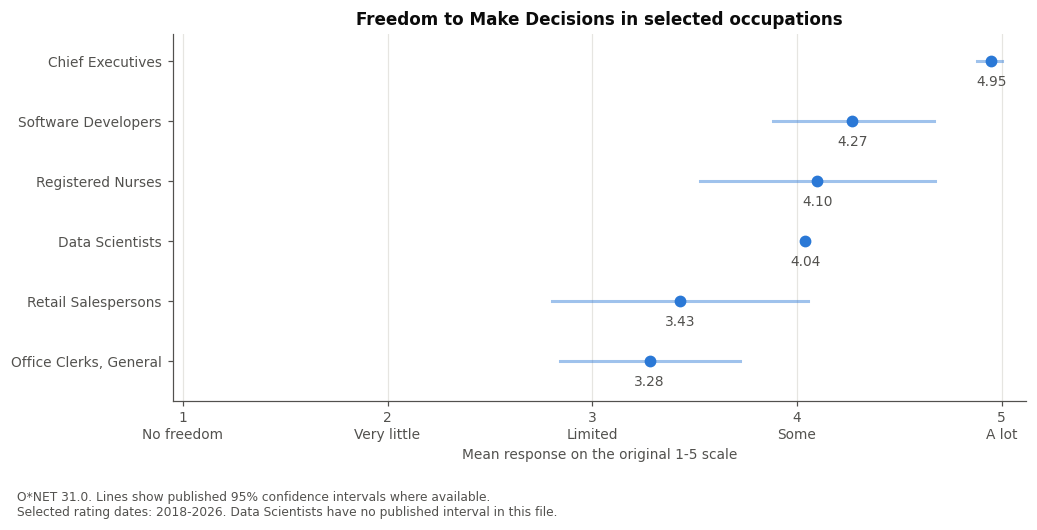

In [32]:
autonomy_titles = ['Chief Executives', 'Software Developers', 'Registered Nurses',
                   'Data Scientists', 'Retail Salespersons', 'Office Clerks, General']
autonomy_example = wc.loc[
    wc['Element Name'].eq('Freedom to Make Decisions') & wc['Scale ID'].eq('CX') &
    wc['Title'].isin(autonomy_titles)
].sort_values('Data Value', ascending=False).copy()
assert len(autonomy_example) == len(autonomy_titles)
assert not autonomy_example['Recommend Suppress'].eq('Y').any()
display(autonomy_example[['O*NET-SOC Code', 'Title', 'Data Value', 'N',
                         'Lower CI Bound', 'Upper CI Bound', 'Date', 'Domain Source']])

fig, ax = plt.subplots(figsize=(9.5, 4.8))
y = np.arange(len(autonomy_example))
for position, (_, row) in enumerate(autonomy_example.iterrows()):
    if pd.notna(row['Lower CI Bound']) and pd.notna(row['Upper CI Bound']):
        ax.plot([row['Lower CI Bound'], row['Upper CI Bound']], [position, position],
                color=BLUE, alpha=0.45, linewidth=2)
ax.scatter(autonomy_example['Data Value'], y, color=BLUE, s=45, zorder=3)
for position, value in enumerate(autonomy_example['Data Value']):
    ax.annotate(f'{value:.2f}', (value, position), xytext=(0, -16),
                textcoords='offset points', ha='center', color=TEXT2, fontsize=9)
ax.set_yticks(y, autonomy_example['Title'])
ax.set_ylim(len(autonomy_example) - 0.35, -0.45)
ax.set_xlim(0.95, 5.12)
ax.set_xticks([1, 2, 3, 4, 5],
              ['1\nNo freedom', '2\nVery little', '3\nLimited', '4\nSome', '5\nA lot'])
ax.grid(axis='y', visible=False)
ax.set_xlabel('Mean response on the original 1-5 scale')
ax.set_title('Freedom to Make Decisions in selected occupations')
fig.text(0.02, 0.015, 'O*NET 31.0. Lines show published 95% confidence intervals where available.\n'
         'Selected rating dates: 2018-2026. Data Scientists have no published interval in this file.',
         fontsize=8, color=TEXT2)
fig.tight_layout(rect=[0, 0.09, 1, 1])
plt.show()

**Observation:** Selected mean ratings range from 3.28 for Office Clerks, General to 4.95 for Chief Executives. Software Developers have a mean of 4.27 and Data Scientists 4.04. Published confidence intervals overlap for several examples; the displayed means do not establish statistically significant occupation differences. Data Scientists use an Occupational Expert rating without a published interval, while the other five use Incumbent ratings.

The item can describe an occupation's autonomy. A person-job autonomy fit measure additionally requires the person's preference for autonomy. A higher rating alone does not establish higher satisfaction or better fit.

### 5.3 Other tables previously inspected

Career Interests, Work Styles and Job Zones are retained below as preliminary inspections. They have not received the detailed scale and quality review used above.

In [33]:
ci = pd.read_csv(V31 / 'career_interest_types.csv')
RIASEC = ['Realistic','Investigative','Artistic','Social','Enterprising','Conventional']
ci_wide = ci[ci['Scale ID']=='OI'].pivot(index='O*NET-SOC Code', columns='Element Name', values='Data Value')[RIASEC]
print('RIASEC occupations covered:', len(ci_wide), '| source:', ci['Domain Source'].unique().tolist(), '| date:', ci['Date'].unique().tolist())
display(ci_wide.describe().round(2))

RIASEC occupations covered: 923 | source: ['Machine Learning/Expert', 'Machine Learning'] | date: ['02/2026', '11/2023']


Element Name,Realistic,Investigative,Artistic,Social,Enterprising,Conventional
count,923.00,923.00,923.00,923.00,923.00,923.00
mean,4.57,3.36,1.94,2.94,2.83,4.53
std,1.93,1.68,1.20,1.75,1.61,0.99
min,1.00,1.00,1.00,1.00,1.00,1.61
25%,2.90,2.02,1.00,1.50,1.54,3.72
50%,4.84,2.92,1.50,2.44,2.36,4.41
75%,6.40,4.77,2.39,3.84,3.77,5.14
max,7.00,7.00,7.00,7.00,7.00,7.00


In [34]:
ws = pd.read_csv(V31 / 'work_styles.csv')
ws_wide = ws[ws['Scale ID']=='WI'].pivot(index='O*NET-SOC Code', columns='Element Name', values='Data Value')
print('Work Styles occupations covered:', len(ws_wide), '| 21 dimensions:', ws_wide.columns.tolist())
print('source:', ws['Domain Source'].unique().tolist(), '| date:', ws['Date'].unique().tolist())
display(ws_wide.describe().round(2).T[['mean','std','min','max']])

Work Styles occupations covered: 891 | 21 dimensions: ['Achievement Orientation', 'Adaptability', 'Attention to Detail', 'Cautiousness', 'Cooperation', 'Dependability', 'Empathy', 'Humility', 'Initiative', 'Innovation', 'Integrity', 'Intellectual Curiosity', 'Leadership Orientation', 'Optimism', 'Perseverance', 'Self-Confidence', 'Self-Control', 'Sincerity', 'Social Orientation', 'Stress Tolerance', 'Tolerance for Ambiguity']
source: ['AI/Expert'] | date: ['12/2025']


,mean,std,min,max
Element Name,,,,
Achievement Orientation,1.45,0.59,0.20,2.91
Adaptability,1.25,0.67,-0.32,2.74
Attention to Detail,2.33,0.48,0.74,3.00
Cautiousness,1.74,0.74,-0.79,3.00
Cooperation,1.44,0.75,-0.18,3.00
Dependability,2.44,0.29,0.95,3.00
Empathy,0.80,0.95,-0.39,3.00
Humility,0.40,0.59,-1.42,2.62
Initiative,1.06,0.63,-0.29,2.50


In [35]:
jz = pd.read_csv(V31 / 'job_zones.csv')
jzr = pd.read_csv(V31 / 'job_zone_reference.csv')
print('Job Zone occupations covered:', len(jz))
display(jz['Job Zone'].value_counts().sort_index().rename('n_occupations').to_frame().T)
display(jzr[['Job Zone','Name','SVP Range']])

Job Zone occupations covered: 923


Job Zone,2,3,4,5
n_occupations,337,208,226,152


,Job Zone,Name,SVP Range
0,2,Job Zone 1-2: Very Little to Some Preparation Needed,(Below 6.0)
1,3,Job Zone Three: Medium Preparation Needed,(6.0 to < 7.0)
2,4,Job Zone Four: Considerable Preparation Needed,(7.0 to < 8.0)
3,5,Job Zone Five: Extensive Preparation Needed,(8.0 and above)


**Observation:** Job Zones in 31.0 have four levels (2, 3, 4, 5; there is no 1). Keep this in mind when comparing with older literature or older GSS years.

## 6. GSS 2024 occupation frequencies and potential O*NET linkage

The respondent key and the occupation key serve different purposes. `year` plus `id` identify a GSS respondent; `occ10` identifies a **Census 2010 occupation**, not a SOC or O*NET code. Multiple respondents share an occupation, and one Census occupation can include multiple SOC occupations.

This section inspects the local files, tabulates occupations with survey weights, and evaluates a candidate bridge:

`GSS OCC10 (Census 2010) -> Census 2018 -> SOC 2018 -> O*NET-SOC 2019`

Sources: [GSS single-year SPSS files](https://gss.norc.org/get-the-data/spss.html), [GSS 2024 codebook](https://gss.norc.org/content/dam/gss/get-documentation/pdf/codebook/GSS%202024%20Codebook%20R3a.pdf), [Census occupation code lists and crosswalks](https://www.census.gov/topics/employment/industry-occupation/guidance/code-lists.html), and [O*NET crosswalks](https://www.onetcenter.org/crosswalks.html). Download URLs and SHA-256 hashes for the added source files are stored in adjacent `.source.json` files. No modeling population or ambiguity rule is selected here.

### 6.1 Local GSS files, raw head and occupation schema

In [36]:
import pyreadstat

GSS = ONET.parent / 'gss'
gss_columns = ['year', 'id', 'occ10', 'satjob', 'wrkstat', 'wtssps',
               'wtssnrps', 'wtssnrps_as', 'baselinestatus', 'amerstatus']
gss_inventory = pd.DataFrame([
    {'file': str(path.relative_to(ONET.parent)), 'size_MB': path.stat().st_size / 1e6}
    for path in sorted(GSS.rglob('*.sav'))
])
display(gss_inventory)

# Read five rows of the large cumulative file, not the full file into memory.
cumulative_head, cumulative_meta = pyreadstat.read_sav(
    GSS / 'GSS_spss' / 'gss7224_r3a.sav',
    usecols=['year', 'id', 'occ10', 'satjob', 'wtssps'], row_limit=5, user_missing=True
)
display(cumulative_head.head())
_, cumulative_schema = pyreadstat.read_sav(GSS / 'GSS_spss' / 'gss7224_r3a.sav', metadataonly=True)
print('Full cumulative file rows / variables:', cumulative_schema.number_rows, cumulative_schema.number_columns)

gss_raw, gss_meta = pyreadstat.read_sav(
    GSS / 'GSS_2024' / 'GSS2024.sav', usecols=gss_columns, user_missing=True
)
display(gss_raw.head())
_, gss_schema = pyreadstat.read_sav(GSS / 'GSS_2024' / 'GSS2024.sav', metadataonly=True)
print('Full single-year file rows / variables:', gss_schema.number_rows, gss_schema.number_columns)
print('Columns loaded for this section:', len(gss_raw.columns))
print('Occupation fields in the single-year schema:',
      [name for name in gss_schema.column_names if name.startswith('occ')])
display(pd.DataFrame({
    'variable': gss_columns,
    'label_from_SAV': [gss_meta.column_names_to_labels[name] for name in gss_columns],
    'declared_missing_ranges': [gss_meta.missing_ranges.get(name, []) for name in gss_columns]
}))

,file,size_MB
0,gss/GSS_2024/GSS2024.sav,21.289470
1,gss/GSS_spss/gss7224_r3a.sav,3821.555224


,year,id,occ10,satjob,wtssps
0,1972.0,1.0,520.0,3.0,0.663196
1,1972.0,2.0,7700.0,-100.0,0.917370
2,1972.0,3.0,4920.0,2.0,0.897413
3,1972.0,4.0,800.0,1.0,1.066341
4,1972.0,5.0,5020.0,-100.0,0.944324


Full cumulative file rows / variables: 75699 6943


,year,id,occ10,satjob,wrkstat,wtssnrps,wtssps,baselinestatus,amerstatus,wtssnrps_as
0,2024.0,1.0,230.0,2.0,1.0,2.369490,1.889989,1.0,0.0,1.663284
1,2024.0,2.0,800.0,-100.0,5.0,1.391160,1.152265,1.0,0.0,1.506088
2,2024.0,3.0,430.0,-100.0,5.0,1.171199,0.915609,1.0,0.0,1.363951
3,2024.0,4.0,4760.0,1.0,2.0,2.735830,2.288064,1.0,0.0,3.796158
4,2024.0,5.0,5860.0,-100.0,5.0,1.272915,1.005427,1.0,0.0,1.504431


Full single-year file rows / variables: 3986 989
Columns loaded for this section: 10
Occupation fields in the single-year schema: ['occ10']


,variable,label_from_SAV,declared_missing_ranges
0,year,GSS year for this respondent,"[{'lo': -100.0, 'hi': -10.0}]"
1,id,Respondent ID number,"[{'lo': -100.0, 'hi': -10.0}]"
2,occ10,R's census occupation code (2010),"[{'lo': -100.0, 'hi': -10.0}]"
3,satjob,Work satisfaction,"[{'lo': -100.0, 'hi': -10.0}]"
4,wrkstat,Labor force status,"[{'lo': -100.0, 'hi': -10.0}]"
5,wtssps,Person post-stratification weight,"[{'lo': -100.0, 'hi': -10.0}]"
6,wtssnrps,"Person post-stratification weight, nonrespondents adjusted","[{'lo': -100.0, 'hi': -10.0}]"
7,wtssnrps_as,POSTSTRATIFICATION AND NONRESPONSE WEIGHT FOR ANALYZING ...,"[{'lo': -100.0, 'hi': -10.0}]"
8,baselinestatus,BASELINE SAMPLE INDICATOR FOR GSS 2022,"[{'lo': -100.0, 'hi': -10.0}]"
9,amerstatus,AMERISPEAK SAMPLE INDICATOR FOR GSS 2022,"[{'lo': -100.0, 'hi': -10.0}]"


**Observation:** The original local file is the 1972-2024 cumulative dataset. The separately downloaded 2024 cross-section has 3,986 rows. The SAV label for `occ10` is "R's census occupation code (2010)". Negative values such as `-100` are declared missing codes, not occupations or satisfaction responses. Some sample-flag labels retain "GSS2022" in the SAV metadata; sample counts below use observed 2024 records and the 2024 documentation.

In [37]:
# Apply the SPSS-declared missing ranges while preserving gss_raw.
gss_2024 = gss_raw.copy()
for variable, ranges in gss_meta.missing_ranges.items():
    if variable in gss_2024:
        for bounds in ranges:
            gss_2024[variable] = gss_2024[variable].mask(
                gss_2024[variable].between(bounds['lo'], bounds['hi'])
            )
gss_2024['census2010'] = gss_2024['occ10'].astype('Int64').astype('string').str.zfill(4)
gss_2024['occupation_label'] = gss_2024['occ10'].map(gss_meta.variable_value_labels['occ10'])
assert gss_2024['year'].eq(2024).all()
assert not gss_2024.duplicated(['year', 'id']).any()
assert gss_2024['occ10'].dropna().ge(0).all()
display(gss_2024[['year', 'id', 'occ10', 'census2010', 'occupation_label', 'satjob']].head())
display(gss_2024.groupby(['baselinestatus', 'amerstatus']).agg(
    respondents=('id', 'size'), valid_OCC10=('occ10', 'count'),
    valid_SATJOB=('satjob', 'count'), valid_WTSSPS=('wtssps', 'count'),
    valid_WTSSNRPS_AS=('wtssnrps_as', 'count')
))
display(gss_2024['wrkstat'].map(gss_meta.variable_value_labels['wrkstat'])
        .value_counts(dropna=False).rename('respondents').to_frame())

,year,id,occ10,census2010,occupation_label,satjob
0,2024.0,1.0,230.0,0230,education administrators,2.0
1,2024.0,2.0,800.0,0800,accountants and auditors,NaN
2,2024.0,3.0,430.0,0430,"managers, all other",NaN
3,2024.0,4.0,4760.0,4760,retail salespersons,1.0
4,2024.0,5.0,5860.0,5860,"office clerks, general",NaN


,,respondents,valid_OCC10,valid_SATJOB,valid_WTSSPS,valid_WTSSNRPS_AS
baselinestatus,amerstatus,,,,,
0.0,1.0,677,610,538,0,677
1.0,0.0,3309,3110,2244,3309,3309


,respondents
wrkstat,
working full time,1823
retired,874
working part time,398
keeping house,329
"unemployed, laid off, looking for work",221
other,130
in school,124
"with a job, but not at work because of temporary illness, vacation, strike",75
NaN,12


### 6.2 Occupation frequencies and sample size

The 2024 file combines 3,309 baseline respondents and 677 AmeriSpeak respondents. The [2024 codebook](https://gss.norc.org/content/dam/gss/get-documentation/pdf/codebook/GSS%202024%20Codebook%20R3a.pdf) describes `wtssps` and `wtssnrps` for the baseline sample and `wtssnrps_as` for the combined sample; `wtssnrps` includes an additional nonresponse adjustment.

The main frequency table uses baseline records with a valid `occ10` and positive `wtssps`. Weighted percentages use the sum of these weights as their denominator. The combined-sample table is a separate comparison using `wtssnrps_as`. Weight sums are survey-weight totals, not observed sample sizes. `n_satjob` counts usable outcome responses; weighted frequency alone does not establish modeling adequacy.

No employment restriction is imposed: retired and other nonworking respondents can have a last occupation. `n_working_satjob` separately counts respondents with `wrkstat` in 1, 2 or 3 and a valid outcome. These values and the satisfaction categories are read from SAV labels.

In [38]:
def occupation_frequencies(frame, weight):
    eligible = frame.loc[frame['census2010'].notna() & frame[weight].gt(0)].copy()
    eligible['has_satjob'] = eligible['satjob'].isin([1, 2, 3, 4])
    eligible['working_satjob'] = eligible['wrkstat'].isin([1, 2, 3]) & eligible['has_satjob']
    eligible['satisfied'] = eligible['satjob'].isin([1, 2])
    eligible['dissatisfied'] = eligible['satjob'].isin([3, 4])
    table = eligible.groupby('census2010').agg(
        occupation=('occupation_label', 'first'), n=('id', 'size'),
        weight_sum=(weight, 'sum'), n_satjob=('has_satjob', 'sum'),
        n_working_satjob=('working_satjob', 'sum'),
        n_satisfied=('satisfied', 'sum'), n_dissatisfied=('dissatisfied', 'sum')
    )
    table['weighted_pct'] = 100 * table['weight_sum'] / table['weight_sum'].sum()
    return table.sort_values('weighted_pct', ascending=False)

baseline = gss_2024.loc[gss_2024['baselinestatus'].eq(1)].copy()
freq_wtssps = occupation_frequencies(baseline, 'wtssps')
freq_combined = occupation_frequencies(gss_2024, 'wtssnrps_as')
print('Baseline WTSSPS occupation frequencies, top 20:')
display(freq_wtssps.head(20).round(3))
print('Combined WTSSNRPS_AS occupation frequencies, top 10:')
display(freq_combined.head(10).round(3))
display(pd.DataFrame({
    'sample': ['Baseline / WTSSPS', 'Combined / WTSSNRPS_AS'],
    'all_respondents': [len(baseline), len(gss_2024)],
    'valid_occupation_and_weight': [int(freq_wtssps['n'].sum()), int(freq_combined['n'].sum())],
    'distinct_occupations': [len(freq_wtssps), len(freq_combined)],
    'valid_occupation_weight_and_SATJOB': [int(freq_wtssps['n_satjob'].sum()), int(freq_combined['n_satjob'].sum())]
}))
print('Illustrative sample-size cutoffs, not selected filters:')
display(pd.DataFrame([
    {'minimum_n_satjob': cutoff, 'occupations': int(freq_wtssps['n_satjob'].ge(cutoff).sum()),
     'retained_outcomes': int(freq_wtssps.loc[freq_wtssps['n_satjob'].ge(cutoff), 'n_satjob'].sum())}
    for cutoff in [5, 10, 20, 30]
]))

Baseline WTSSPS occupation frequencies, top 20:


,occupation,n,weight_sum,n_satjob,n_working_satjob,n_satisfied,n_dissatisfied,weighted_pct
census2010,,,,,,,,
0430,"managers, all other",84,90.223,63,60,55,8,2.939
9130,driver/sales workers and truck drivers,65,84.091,45,39,35,10,2.739
4760,retail salespersons,64,73.884,48,35,39,9,2.406
2310,elementary and middle school teachers,80,73.800,42,33,34,8,2.404
4700,first-line supervisors of retail sales workers,51,69.113,33,29,25,8,2.251
3600,"nursing, psychiatric, and home health aides",78,58.491,48,40,45,3,1.905
5700,secretaries and administrative assistants,61,51.647,32,18,30,2,1.682
5240,customer service representatives,56,47.250,50,38,41,9,1.539
3255,registered nurses,60,45.437,36,35,32,4,1.480


Combined WTSSNRPS_AS occupation frequencies, top 10:


,occupation,n,weight_sum,n_satjob,n_working_satjob,n_satisfied,n_dissatisfied,weighted_pct
census2010,,,,,,,,
9130,driver/sales workers and truck drivers,74,102.837,52,45,41,11,2.780
0430,"managers, all other",96,102.798,74,71,61,13,2.779
4760,retail salespersons,76,100.696,59,41,47,12,2.722
2310,elementary and middle school teachers,94,86.976,54,43,44,10,2.351
4700,first-line supervisors of retail sales workers,59,71.413,39,34,31,8,1.930
3600,"nursing, psychiatric, and home health aides",87,68.286,54,46,51,3,1.846
5700,secretaries and administrative assistants,75,67.821,41,27,38,3,1.833
4720,cashiers,64,60.828,49,29,26,23,1.644
5240,customer service representatives,77,60.652,69,53,57,12,1.639


,sample,all_respondents,valid_occupation_and_weight,distinct_occupations,valid_occupation_weight_and_SATJOB
0,Baseline / WTSSPS,3309,3110,366,2144
1,Combined / WTSSNRPS_AS,3986,3720,383,2640


Illustrative sample-size cutoffs, not selected filters:


,minimum_n_satjob,occupations,retained_outcomes
0,5,125,1756
1,10,64,1351
2,20,22,767
3,30,14,570


**Observation:** The top-frequency table reports both weighted occupation prevalence and raw outcome counts. The cutoff table exposes the sample-size cost of analyzing detailed occupations separately. It does not define "high skill" or select a study population.

### 6.3 Inspect the official bridge tables

The [Census workbook](https://www2.census.gov/programs-surveys/demo/guidance/industry-occupation/2018-occupation-code-list-and-crosswalk.xlsx) includes the Census 2010-to-2018 crosswalk and the 2018 Census-to-SOC list. The crosswalk is an editorial worksheet with split headers, merged categories and subordinate titles, rather than a flat two-key table. Forward-filling both code columns would create false edges between adjacent occupations.

The parser below retains directly paired rows, explicit split blocks, and merge rows with a subordinate target title or source rows immediately below a target-only header. Source-only rows and target headers that cannot be resolved under these rules remain in audit tables. Missing edges can affect candidate sets even for a source that has another parsed match. Thus the resulting bridge is **provisional** and its candidate counts can understate ambiguity until unresolved rows are reconciled. No text similarity or prefix guess assigns an occupation.

In [39]:
census_book = ONET / '2018-occupation-code-list-and-crosswalk.xlsx'
census_crosswalk_raw = pd.read_excel(census_book, sheet_name='2010 to 2018 Crosswalk ', header=3, dtype=str)
display(census_crosswalk_raw.head())
census_list_raw = pd.read_excel(census_book, sheet_name='2018 Census Occ Code List', header=4, dtype=str)
display(census_list_raw.head())
census_detail_raw = pd.read_excel(census_book, sheet_name='Summary of 2018 Changes', header=2, dtype=str)
display(census_detail_raw.head())
cw = pd.read_excel(ONET / 'onetsoc2019_to_soc2018_crosswalk.xlsx', header=3, dtype=str)
display(cw.head())
print('O*NET / SOC distinct codes:', cw['O*NET-SOC 2019 Code'].nunique(), cw['2018 SOC Code'].nunique())

,2010 SOC code,2010 Census Code,2010 Census Title \n,2018 SOC Code,2018 Census Code,2018 Census Title
0,11-1011,0010,Chief Executives,11-1011,0010,Chief Executives
1,11-1021,0020,General and Operations Managers,11-1021,0020,General and Operations Managers
2,11-1031,0030,Legislators,11-1031,0030,Legislators
3,11-2011,0040,Advertising and Promotions Managers,11-2011,0040,Advertising and Promotions Managers
4,11-2020,0050,Marketing and Sales Managers,NaN,NaN,NaN


,Unnamed: 0,2018 Census Title,2018 Census Code,2018 SOC Code
0,NaN,NaN,NaN,NaN
1,NaN,The 2018 census occupation classification list has 570 c...,NaN,NaN
2,NaN,NaN,NaN,NaN
3,"Management, Business, Science, and Arts Occupations:",NaN,0010-3550,11-0000 - 29-0000
4,NaN,NaN,NaN,NaN


,2018 SOC Code,2018 Census Code,2018 Census Title,Census No Change,Census New Occupation,Census Code Change,Census Title Change
0,11-1011,0010,Chief Executives,x,NaN,NaN,NaN
1,11-1021,0020,General and Operations Managers,x,NaN,NaN,NaN
2,11-1031,0030,Legislators,x,NaN,NaN,NaN
3,11-2011,0040,Advertising and Promotions Managers,x,NaN,NaN,NaN
4,11-2021,0051,Marketing Managers,NaN,x,NaN,NaN


,O*NET-SOC 2019 Code,O*NET-SOC 2019 Title,2018 SOC Code,2018 SOC Title
0,11-1011.00,Chief Executives,11-1011,Chief Executives
1,11-1011.03,Chief Sustainability Officers,11-1011,Chief Executives
2,11-1021.00,General and Operations Managers,11-1021,General and Operations Managers
3,11-1031.00,Legislators,11-1031,Legislators
4,11-2011.00,Advertising and Promotions Managers,11-2011,Advertising and Promotions Managers


O*NET / SOC distinct codes: 1016 867


In [40]:
import re

census_x = census_crosswalk_raw.rename(columns=lambda name: name.strip()).copy()
def is_census_code(value):
    return isinstance(value, str) and re.fullmatch(r'\d{4}', value) is not None

bridge_rows = []
split_source = None
merge_target = None
merge_blank_allowed = False
for row_index, row in census_x.iterrows():
    old = row['2010 Census Code']
    new = row['2018 Census Code']
    has_old, has_new = is_census_code(old), is_census_code(new)
    if has_old and has_new:
        bridge_rows.append((old, new, row_index, 'same row'))
        split_source = None
        merge_target = new
        merge_blank_allowed = False
    elif has_old:
        if pd.isna(row['2018 Census Title']):
            if merge_blank_allowed and merge_target is not None:
                bridge_rows.append((old, merge_target, row_index, 'merge source below target header'))
            else:
                split_source = old
                merge_target = None
        else:
            merge_blank_allowed = False
            if merge_target is not None:
                bridge_rows.append((old, merge_target, row_index, 'merge subordinate row'))
            split_source = None
    elif has_new:
        if split_source is not None:
            bridge_rows.append((split_source, new, row_index, 'split continuation'))
        merge_target = new
        merge_blank_allowed = split_source is None
    elif pd.notna(row['2018 Census Title']):
        merge_blank_allowed = False

census_bridge = pd.DataFrame(bridge_rows, columns=['census2010', 'census2018', 'source_row', 'parse_rule'])
census_bridge = census_bridge.drop_duplicates(['census2010', 'census2018'])
old_titles = census_x.loc[census_x['2010 Census Code'].map(is_census_code),
                          ['2010 Census Code', '2010 Census Title', '2010 SOC code']].drop_duplicates()
old_titles = old_titles.rename(columns={'2010 Census Code': 'census2010'})
unresolved_census = old_titles.loc[~old_titles['census2010'].isin(census_bridge['census2010'])]
print('Parsed Census 2010 / Census 2018 / edges:',
      census_bridge['census2010'].nunique(), census_bridge['census2018'].nunique(), len(census_bridge))
print('Source rows requiring reconciliation:')
display(unresolved_census.merge(freq_wtssps[['n', 'n_satjob']], on='census2010', how='left'))
display(census_bridge.head())
print('Target headers not reached by the provisional parser:')
display(census_x.loc[census_x['2018 Census Code'].map(is_census_code) &
                    ~census_x['2018 Census Code'].isin(census_bridge['census2018']),
                    ['2018 Census Code', '2018 Census Title']])

Parsed Census 2010 / Census 2018 / edges: 535 567 599
Source rows requiring reconciliation:


,census2010,2010 Census Title,2010 SOC code,n,n_satjob
0,4410,Motion Picture Projectionists,39-3021,NaN,NaN
1,5800,Computer Operators,43-9011,NaN,NaN
2,6930,Helpers--Extraction Workers,47-5081,NaN,NaN
3,7600,Signal and Track Switch Repairers,49-9097,NaN,NaN
4,9730,Mine Shuttle Car Operators,53-7111,NaN,NaN


,census2010,census2018,source_row,parse_rule
0,0010,0010,0,same row
1,0020,0020,1,same row
2,0030,0030,2,same row
3,0040,0040,3,same row
4,0050,0051,5,split continuation


Target headers not reached by the provisional parser:


,2018 Census Code,2018 Census Title
44,0426,"Personal Service Managers, All Other"
60,0705,Project Management Specialists
1021,6821,"Excavating and Loading Machine and Dragline Operators, S..."


The 2018 Census list contains detailed SOC codes, hierarchy codes such as `25-1000`, and residual notation such as `13-20XX`. Residual categories use the explicitly enumerated SOC codes in "Summary of 2018 Changes". Hierarchy categories use membership from the published SOC structure. An `X` is not expanded to every code sharing a prefix, because some of those codes belong to other Census categories.

In [41]:
detail = census_detail_raw.rename(columns=lambda name: name.strip()).copy()
detail['census2018'] = detail['2018 Census Code'].where(detail['2018 Census Code'].map(is_census_code)).ffill()
census_list = census_list_raw.rename(columns=lambda name: name.strip())
census_list = census_list.loc[census_list['2018 Census Code'].map(is_census_code)]

# Reset subordinate hierarchy columns at parent boundaries before carrying labels down.
hierarchy = pd.read_csv(ONET / 'soc_2018_structure.csv', dtype=str)
display(hierarchy.head())
parent_columns = ['Major Group', 'Minor Group', 'Broad Occupation']
active = dict.fromkeys(parent_columns)
hierarchy_members = []
for _, row in hierarchy.iterrows():
    for position, column in enumerate(parent_columns):
        if pd.notna(row[column]):
            active[column] = row[column]
            for child in parent_columns[position + 1:]:
                active[child] = None
    if pd.notna(row['Detailed Occupation']):
        hierarchy_members.append({**active, 'soc2018': row['Detailed Occupation']})
hierarchy_members = pd.DataFrame(hierarchy_members)
soc_codes = set(cw['2018 SOC Code'])
census_soc_rows = []
for _, row in census_list.iterrows():
    census_code, notation = row['2018 Census Code'], row['2018 SOC Code']
    titles = detail.loc[detail['census2018'].eq(census_code), '2018 Census Title'].dropna()
    explicit = sorted({soc_code for title in titles for soc_code in re.findall(r'\((\d{2}-\d{4})\)', title)})
    if explicit:
        members = []
        for reference in explicit:
            if reference in soc_codes:
                members.append(reference)
            else:
                members.extend(hierarchy_members.loc[
                    hierarchy_members[parent_columns].eq(reference).any(axis=1), 'soc2018'
                ].tolist())
        rule = 'enumerated SOC titles, expanding published hierarchy references'
    elif notation in soc_codes:
        members, rule = [notation], 'detailed SOC'
    else:
        members = hierarchy_members.loc[hierarchy_members[parent_columns].eq(notation).any(axis=1), 'soc2018'].tolist()
        rule = 'published hierarchy'
    for soc_code in members:
        census_soc_rows.append((census_code, soc_code, rule))
census_soc = pd.DataFrame(census_soc_rows, columns=['census2018', 'soc2018', 'soc_rule']).drop_duplicates()
assert set(census_soc['soc2018']).issubset(soc_codes)
print('Census 2018 codes with SOC candidates:', census_soc['census2018'].nunique(), '/', len(census_list))
print('Census categories without a SOC candidate:')
display(census_list.loc[~census_list['2018 Census Code'].isin(census_soc['census2018']),
                        ['2018 Census Code', '2018 Census Title', '2018 SOC Code']])
display(census_soc.head())

,Major Group,Minor Group,Broad Occupation,Detailed Occupation,Detailed O*NET-SOC,SOC or O*NET-SOC 2019 Title
0,11-0000,NaN,NaN,NaN,NaN,Management Occupations
1,NaN,11-1000,NaN,NaN,NaN,Top Executives
2,NaN,NaN,11-1010,NaN,NaN,Chief Executives
3,NaN,NaN,NaN,11-1011,NaN,Chief Executives
4,NaN,NaN,NaN,NaN,11-1011.03,Chief Sustainability Officers


Census 2018 codes with SOC candidates: 568 / 570
Census categories without a SOC candidate:


,2018 Census Code,2018 Census Title,2018 SOC Code
660,9830,"Military, rank not Specified",none
661,9920,"Unemployed, with no work experience in the last 5 years ...",none


,census2018,soc2018,soc_rule
0,0010,11-1011,detailed SOC
1,0020,11-1021,detailed SOC
2,0030,11-1031,detailed SOC
3,0040,11-2011,detailed SOC
4,0051,11-2021,detailed SOC


### 6.4 Candidate mappings, respondent coverage and a merge preview

Crosswalk merges are allowed to expand the **lookup table**. They must not expand the respondent table: multiple candidate occupations for one person are uncertainty, not extra people. Candidate summaries are attached with `validate='many_to_one'`. The preview attaches an O*NET profile only when the provisional candidate set contains exactly one code; unresolved and multiple-candidate records retain missing profile values.

A unique candidate in this exploratory parser is not a final validated occupational assignment. Census revision splits may also contain new occupations that cannot be identified separately in an older code. The raw survey does not resolve that uncertainty.

In [42]:
onet_bridge = cw.rename(columns={'2018 SOC Code': 'soc2018',
                                  'O*NET-SOC 2019 Code': 'onet_code',
                                  'O*NET-SOC 2019 Title': 'onet_title'})
candidate_bridge = census_bridge.merge(census_soc, on='census2018', how='inner').merge(
    onet_bridge[['soc2018', 'onet_code', 'onet_title']], on='soc2018', how='inner', validate='many_to_many'
)
candidate_pairs = candidate_bridge[['census2010', 'soc2018', 'onet_code', 'onet_title']].drop_duplicates()
wv_codes = set(wv_wide.index)
skill_codes = set(skill_im_raw.index)
candidate_pairs['has_work_values'] = candidate_pairs['onet_code'].isin(wv_codes)
candidate_pairs['has_essential_skills'] = candidate_pairs['onet_code'].isin(skill_codes)
candidate_summary = candidate_pairs.groupby('census2010').agg(
    n_soc_candidates=('soc2018', 'nunique'), n_onet_candidates=('onet_code', 'nunique'),
    n_candidates_with_work_values=('has_work_values', 'sum'),
    n_candidates_with_skills=('has_essential_skills', 'sum')
)
print('Candidate bridge head:')
display(candidate_pairs.head())
linkage_audit = gss_2024.merge(candidate_summary, on='census2010', how='left', validate='many_to_one')
linkage_audit['mapping_status'] = np.select(
    [linkage_audit['census2010'].isna(), linkage_audit['n_onet_candidates'].isna(),
     linkage_audit['n_onet_candidates'].eq(1)],
    ['Missing OCC10', 'No parsed O*NET candidate', 'One provisional O*NET candidate'],
    default='Multiple O*NET candidates'
)
assert len(linkage_audit) == len(gss_2024)
linkage_audit['baseline_weight'] = linkage_audit['wtssps'].where(linkage_audit['baselinestatus'].eq(1))
linkage_audit['baseline_satjob'] = linkage_audit['baselinestatus'].eq(1) & linkage_audit['satjob'].isin([1, 2, 3, 4])
coverage = linkage_audit.groupby('mapping_status').agg(
    all_respondents=('id', 'size'), baseline_respondents=('baseline_weight', 'count'),
    baseline_weight_sum=('baseline_weight', 'sum'), baseline_valid_satjob=('baseline_satjob', 'sum')
)
coverage['baseline_weighted_pct_all'] = 100 * coverage['baseline_weight_sum'] / baseline['wtssps'].sum()
display(coverage.round(3))
print('Observed occupation codes with no parsed O*NET candidates:')
display(freq_wtssps.loc[~freq_wtssps.index.isin(candidate_summary.index), ['occupation', 'n', 'n_satjob']])
print('Top baseline occupations and candidate counts:')
display(freq_wtssps.join(candidate_summary).head(15).round(3))

Candidate bridge head:


,census2010,soc2018,onet_code,onet_title,has_work_values,has_essential_skills
0,0010,11-1011,11-1011.00,Chief Executives,True,True
1,0010,11-1011,11-1011.03,Chief Sustainability Officers,True,True
2,0020,11-1021,11-1021.00,General and Operations Managers,True,True
3,0030,11-1031,11-1031.00,Legislators,True,False
4,0040,11-2011,11-2011.00,Advertising and Promotions Managers,True,True


,all_respondents,baseline_respondents,baseline_weight_sum,baseline_valid_satjob,baseline_weighted_pct_all
mapping_status,,,,,
Missing OCC10,266,199,238.654,100,7.212
Multiple O*NET candidates,1991,1673,1618.125,1133,48.901
No parsed O*NET candidate,16,14,13.015,6,0.393
One provisional O*NET candidate,1713,1423,1439.206,1005,43.494


Observed occupation codes with no parsed O*NET candidates:


,occupation,n,n_satjob
census2010,,,
9830,"military, rank not specified",14,6


Top baseline occupations and candidate counts:


,occupation,n,weight_sum,n_satjob,n_working_satjob,n_satisfied,n_dissatisfied,weighted_pct,n_soc_candidates,n_onet_candidates,n_candidates_with_work_values,n_candidates_with_skills
census2010,,,,,,,,,,,,
0430,"managers, all other",84,90.223,63,60,55,8,2.939,1.0,7.0,6.0,6.0
9130,driver/sales workers and truck drivers,65,84.091,45,39,35,10,2.739,3.0,3.0,3.0,3.0
4760,retail salespersons,64,73.884,48,35,39,9,2.406,1.0,1.0,1.0,1.0
2310,elementary and middle school teachers,80,73.800,42,33,34,8,2.404,3.0,3.0,3.0,3.0
4700,first-line supervisors of retail sales workers,51,69.113,33,29,25,8,2.251,1.0,1.0,1.0,1.0
3600,"nursing, psychiatric, and home health aides",78,58.491,48,40,45,3,1.905,4.0,4.0,4.0,4.0
5700,secretaries and administrative assistants,61,51.647,32,18,30,2,1.682,4.0,4.0,4.0,4.0
5240,customer service representatives,56,47.250,50,38,41,9,1.539,1.0,1.0,1.0,1.0
3255,registered nurses,60,45.437,36,35,32,4,1.480,1.0,5.0,5.0,5.0


In [43]:
# Candidate cardinality determines eligibility for this preview only.
unique_codes = candidate_summary.index[candidate_summary['n_onet_candidates'].eq(1)]
unique_lookup = candidate_pairs.loc[candidate_pairs['census2010'].isin(unique_codes),
                                     ['census2010', 'onet_code', 'onet_title']].drop_duplicates()
assert unique_lookup['census2010'].is_unique
person_preview = linkage_audit.merge(unique_lookup, on='census2010', how='left', validate='many_to_one')
skill_for_join = skill_im.rename(columns=lambda name: 'skill_IM_' + name.replace(' ', '_'))
person_preview = person_preview.merge(skill_for_join, left_on='onet_code', right_index=True,
                                      how='left', validate='many_to_one')
assert len(person_preview) == len(gss_2024)
assert not person_preview.duplicated(['year', 'id']).any()
preview_columns = ['year', 'id', 'census2010', 'occupation_label', 'satjob',
                   'mapping_status', 'onet_code', 'onet_title'] + skill_for_join.columns.tolist()[:3]
display(person_preview[preview_columns].head())
print('Examples with a provisional profile attached:')
display(person_preview.loc[person_preview['onet_code'].notna(), preview_columns].head())
print('Retained respondent rows:', len(person_preview))

,year,id,census2010,occupation_label,satjob,mapping_status,onet_code,onet_title,skill_IM_Reading_Comprehension,skill_IM_Active_Listening,skill_IM_Writing
0,2024.0,1.0,0230,education administrators,2.0,Multiple O*NET candidates,NaN,NaN,NaN,NaN,NaN
1,2024.0,2.0,0800,accountants and auditors,NaN,One provisional O*NET candidate,13-2011.00,Accountants and Auditors,3.88,3.50,3.50
2,2024.0,3.0,0430,"managers, all other",NaN,Multiple O*NET candidates,NaN,NaN,NaN,NaN,NaN
3,2024.0,4.0,4760,retail salespersons,1.0,One provisional O*NET candidate,41-2031.00,Retail Salespersons,3.00,3.75,3.00
4,2024.0,5.0,5860,"office clerks, general",NaN,One provisional O*NET candidate,43-9061.00,"Office Clerks, General",3.75,3.75,3.12


Examples with a provisional profile attached:


,year,id,census2010,occupation_label,satjob,mapping_status,onet_code,onet_title,skill_IM_Reading_Comprehension,skill_IM_Active_Listening,skill_IM_Writing
1,2024.0,2.0,0800,accountants and auditors,NaN,One provisional O*NET candidate,13-2011.00,Accountants and Auditors,3.88,3.50,3.50
3,2024.0,4.0,4760,retail salespersons,1.0,One provisional O*NET candidate,41-2031.00,Retail Salespersons,3.00,3.75,3.00
4,2024.0,5.0,5860,"office clerks, general",NaN,One provisional O*NET candidate,43-9061.00,"Office Clerks, General",3.75,3.75,3.12
5,2024.0,6.0,4000,chefs and head cooks,1.0,One provisional O*NET candidate,35-1011.00,Chefs and Head Cooks,3.50,3.62,3.12
6,2024.0,7.0,9640,"packers and packagers, hand",1.0,One provisional O*NET candidate,53-7064.00,"Packers and Packagers, Hand",2.62,2.75,2.00


Retained respondent rows: 3986


**Observation:** The preview preserves one row per respondent and distinguishes no candidate, one candidate and multiple candidates. The attached IM columns are occupational skill requirements, not measurements of the respondent's own skill. Missing occupations or missing O*NET ratings remain missing rather than being converted to zero.

In [44]:
# Find computing-related examples by official titles, not a hand-written code mapping.
computing_mask = old_titles['2010 Census Title'].str.contains(
    r'Computer|Software|Web|Database|Mathematical', case=False, na=False
)
computing_examples = old_titles.loc[computing_mask, ['census2010', '2010 Census Title']]
display(computing_examples.merge(freq_wtssps[['n', 'n_satjob']], on='census2010', how='left')
        .merge(candidate_summary, on='census2010', how='left'))
print('Where a Data Scientist profile appears in the candidate bridge:')
display(candidate_pairs.loc[candidate_pairs['onet_title'].str.contains('Data Scientists', na=False)]
        .merge(old_titles[['census2010', '2010 Census Title']], on='census2010', how='left'))
print('Multiple-candidate examples among the five largest baseline occupations:')
example_codes = freq_wtssps.head(5).index
examples = candidate_pairs.loc[candidate_pairs['census2010'].isin(example_codes)]
display(examples.head(25))

,census2010,2010 Census Title,n,n_satjob,n_soc_candidates,n_onet_candidates,n_candidates_with_work_values,n_candidates_with_skills
0,0110,Computer and Information Systems Managers,16.0,9.0,1.0,1.0,1.0,1.0
1,1005,Computer and Information Research Scientists,NaN,NaN,1.0,1.0,1.0,1.0
2,1006,Computer Systems Analysts,11.0,7.0,1.0,2.0,2.0,2.0
3,1107,"Computer Occupations, All Other",12.0,9.0,1.0,10.0,5.0,9.0
4,1010,Computer Programmers,8.0,3.0,1.0,1.0,1.0,1.0
5,1020,"Software Developers, Applications and Systems Software",33.0,28.0,2.0,2.0,1.0,2.0
6,1050,Computer Support Specialists,15.0,11.0,2.0,2.0,2.0,2.0
7,1060,Database Administrators,NaN,NaN,2.0,3.0,3.0,3.0
8,1105,Network and Computer Systems Administrators,4.0,4.0,1.0,1.0,1.0,1.0
9,1030,Web Developers,5.0,4.0,2.0,3.0,2.0,3.0


Where a Data Scientist profile appears in the candidate bridge:


,census2010,soc2018,onet_code,onet_title,has_work_values,has_essential_skills,2010 Census Title
0,1240,15-2051,15-2051.00,Data Scientists,False,True,Miscellaneous Mathematical Science Occupations


Multiple-candidate examples among the five largest baseline occupations:


,census2010,soc2018,onet_code,onet_title,has_work_values,has_essential_skills
49,0430,11-9199,11-9199.00,"Managers, All Other",False,False
50,0430,11-9199,11-9199.01,Regulatory Affairs Managers,True,True
51,0430,11-9199,11-9199.02,Compliance Managers,True,True
52,0430,11-9199,11-9199.08,Loss Prevention Managers,True,True
53,0430,11-9199,11-9199.09,Wind Energy Operations Managers,True,True
54,0430,11-9199,11-9199.10,Wind Energy Development Managers,True,True
55,0430,11-9199,11-9199.11,Brownfield Redevelopment Specialists and Site Managers,True,True
331,2310,25-2021,25-2021.00,"Elementary School Teachers, Except Special Education",True,True
332,2310,25-2022,25-2022.00,"Middle School Teachers, Except Special and Career/Techni...",True,True
333,2310,25-2023,25-2023.00,"Career/Technical Education Teachers, Middle School",True,True


### 6.5 Potential merge strategies and remaining choices

| Strategy | Resulting respondent features | Main limitation |
|---|---|---|
| Validated unique occupation links | One O*NET profile per linked person, as illustrated in 6.4 | Excludes unresolved and ambiguous occupations; selection can change the study population |
| Aggregate O*NET profiles to Census 2010 | One feature vector per Census code, then a many-to-one person merge | Requires a justified specialty and revision-split aggregation rule; an unweighted mean is an assumption |
| Occupational group analysis | Coarser group features and larger cell counts | Loses occupation detail; classification changes can cross groups |

The provisional crosswalk needs reconciliation of its unresolved source rows before any production merge. A candidate table does not supply employment shares within Census categories. Employment weights would require an additional source and a compatible taxonomy. A sensitivity analysis could compare plausible aggregation rules and the unique-link subset, with coverage reported for each outcome sample.

For skill indicators, Section 5.1 established that all 910 covered Essential Skills occupations have the same ten skill records. `get_dummies` on record presence would therefore produce constant columns on the covered sample. Joining the continuous IM/LV ratings, or evaluating explicit rating cutoffs, can vary across occupations; a cutoff still needs a substantive definition. Neither approach measures person-job fit without a compatible personal measure.

Detailed occupations such as Data Scientists cannot necessarily be isolated from a Census 2010 category. Inspect the printed candidate set before defining a computing or high-skill subpopulation. Raw outcome counts and satisfaction class counts in 6.2, rather than weighted prevalence alone, determine how much information that subpopulation contains.

In [45]:
# Potential linkage is separate from feature availability: audit every candidate.
feature_audit = candidate_pairs.groupby('census2010').agg(
    n_candidates=('onet_code', 'nunique'),
    n_with_work_values=('has_work_values', 'sum'),
    n_with_skills=('has_essential_skills', 'sum')
)
feature_audit['all_candidates_have_work_values'] = feature_audit['n_with_work_values'].eq(feature_audit['n_candidates'])
feature_audit['all_candidates_have_skills'] = feature_audit['n_with_skills'].eq(feature_audit['n_candidates'])
display(freq_wtssps.join(feature_audit).head(15).round(3))

# Preserve the earlier SOC-level Work Values coverage calculation as a feature audit.
wv_soc = wv_wide.join(cw.set_index('O*NET-SOC 2019 Code')['2018 SOC Code']).groupby('2018 SOC Code')[WV_ORDER].mean()
print('SOC codes with any Work Values after an illustrative specialty mean:', len(wv_soc), '/', len(soc_codes))
print('This mean is not used for the GSS preview or a final fit model.')

,occupation,n,weight_sum,n_satjob,n_working_satjob,n_satisfied,n_dissatisfied,weighted_pct,n_candidates,n_with_work_values,n_with_skills,all_candidates_have_work_values,all_candidates_have_skills
census2010,,,,,,,,,,,,,
0430,"managers, all other",84,90.223,63,60,55,8,2.939,7.0,6.0,6.0,False,False
9130,driver/sales workers and truck drivers,65,84.091,45,39,35,10,2.739,3.0,3.0,3.0,True,True
4760,retail salespersons,64,73.884,48,35,39,9,2.406,1.0,1.0,1.0,True,True
2310,elementary and middle school teachers,80,73.800,42,33,34,8,2.404,3.0,3.0,3.0,True,True
4700,first-line supervisors of retail sales workers,51,69.113,33,29,25,8,2.251,1.0,1.0,1.0,True,True
3600,"nursing, psychiatric, and home health aides",78,58.491,48,40,45,3,1.905,4.0,4.0,4.0,True,True
5700,secretaries and administrative assistants,61,51.647,32,18,30,2,1.682,4.0,4.0,4.0,True,True
5240,customer service representatives,56,47.250,50,38,41,9,1.539,1.0,1.0,1.0,True,True
3255,registered nurses,60,45.437,36,35,32,4,1.480,5.0,5.0,5.0,True,True


SOC codes with any Work Values after an illustrative specialty mean: 760 / 867
This mean is not used for the GSS preview or a final fit model.


**Observation:** A mapping candidate may lack Work Values even when its Essential Skills are available. Feature-specific coverage must be assessed on the selected GSS outcome sample. The SOC-level mean above reproduces an earlier availability check; it neither resolves Census ambiguity nor imputes missing profiles.

## 7. Occupation standards in NSCG 2023 and Gallup AJQS 2025

NSCG and Gallup use occupation keys that differ from GSS OCC10. This section checks the raw fields, published classification and codebook-defined non-occupation values before considering an O*NET link.

### 7.1 NSCG 2023: NCSES Taxonomy of Occupations

The [NSCG 2023 technical notes](https://ncses.nsf.gov/surveys/national-survey-college-graduates/2023#technical-notes) identify the **NCSES Taxonomy of Occupations, released in 2020 and aligned with SOC 2018**. The 2017-2021 cycles used a taxonomy aligned with SOC 2010. NCSES codes remain a separate coding system; SOC alignment does not make the six-digit survey values SOC codes.

Local definitions and value labels come from `Dpcg23.xlsx` and `Ppcg23.sas` in the [official NSCG public-use package](https://ncses.nsf.gov/explore-data/microdata/national-survey-college-graduates). The local `README.TXT` identifies the September 11, 2025 data version and corrected occupation labels. [Technical Table A-2](https://ncses.nsf.gov/pubs/nsf25322/assets/technical-tables/tables/nsf25322-taba-002.pdf) lists the NCSES occupation hierarchy.

In [46]:
NSCG = ONET.parent / 'nscg' / 'pcg23Public'
nscg_dictionary = pd.read_excel(NSCG / 'Dpcg23.xlsx', dtype=str)
display(nscg_dictionary.head())

# Codes are strings, including the codebook's logical skips.
nscg_columns = ['N3OCPR', 'N3OCPRX', 'N3OCPRNG', 'N2OCPRMG',
                'N2OCPRBG', 'N3OCLST', 'WRKG']
nscg_raw = pd.read_csv(NSCG / 'epcg23.csv', usecols=nscg_columns, dtype='string')
display(nscg_raw.head())
print('Respondent rows / columns loaded:', nscg_raw.shape)
nscg_schema = nscg_dictionary.loc[
    nscg_dictionary['SAS_NAME'].isin(nscg_columns),
    ['SAS_NAME', 'DESCRIPTION', 'DOMAIN', 'SAS_FMT']
]
display(nscg_schema)

/opt/miniconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,SAS_NAME,SESTAT_NAME,DESCRIPTION,SOURCE,QUESTION,DOMAIN,SAS_FMT
0,ACADV,N_ED_REF_WK_ENROLL_REAS_ADVANCEMT,Reason for taking courses during reference week: increas...,CG0: D15.6/CGN: D19.6/CGNR: D15.6,For which of the following reasons were you taking cours...,Took courses/enrolled in college/university during the w...,$YES_NO_CODES
1,ACCAR,N_ED_REF_WK_ENROLL_REAS_BEGIN_CAREER,Reason for taking courses during reference week: further...,CG0: D15.1/CGN: D19.1/CGNR: D15.1,For which of the following reasons were you taking class...,Took courses/enrolled in college/university during the w...,$YES_NO_CODES
2,ACCCEP,N_ED_REF_WK_EMP_ASSISTANCE,School related costs for course taking paid by employer,CG0: D16/CGN: D20/CGNR: D16,Were any of your school-related costs for taking courses...,Took courses/enrolled in college/university during refer...,$YES_NO_CODES
3,ACCHG,N_ED_REF_WK_ENROLL_REAS_CHG_FLD,Reason for taking courses during reference week: change ...,CG0: D15.3/CGN: D19.3/CGNR: D15.3,For which of the following reasons were you taking class...,Took courses/enrolled in college/university during the w...,$YES_NO_CODES
4,ACDRG,N_ED_REF_WK_WORK_DEGREE,Type of degree working on during reference week,CG0: D12/CGN: D16/CGNR: D12,Toward what degree were you working?,Took courses/enrolled in college/university during the w...,$DEGREE_CODES


,N2OCPRBG,N2OCPRMG,N3OCLST,N3OCPR,N3OCPRNG,N3OCPRX,WRKG
0,1,1,999989,110610,11,110610,Y
1,1,1,999989,121730,12,121730,Y
2,3,7,999989,732550,73,732550,Y
3,3,7,999989,721510,72,721510,Y
4,4,8,781250,999989,98,999989,N


Respondent rows / columns loaded: (94606, 7)


,SAS_NAME,DESCRIPTION,DOMAIN,SAS_FMT
372,N2OCPRBG,Job code for principal job (broad group),"Working during the week of February 1, 2023",$OCC19BROAD
373,N2OCPRMG,Job code for principal job (major group),"Working during the week of February 1, 2023",$MAJOR_OCC_GROUP_CODES_NEW
374,N3OCLST,Job code for last job - best code,"Not working during the week of February 1, 2023, except ...",$OCC23CNT
377,N3OCPR,Job code for principal job - best code,"Working during the week of February 1, 2023",$OCC23CNT
378,N3OCPRNG,Job code for principal job (minor group),"Working during the week of February 1, 2023",$OC23PNG
379,N3OCPRX,Job code for principal job - reported code (do not use f...,"Working during the week of February 1, 2023",$OCC23CNT
537,WRKG,Working for pay or profit during reference week,All respondents,$YES_NO_CODES


**Observation:** `N3OCPR` is the principal-job **best code**. The dictionary says to use it for analysis rather than the reported code `N3OCPRX`. `N3OCPRNG`, `N2OCPRMG` and `N2OCPRBG` are NCSES minor, major and broad groups. Their group names and numbers are not the SOC hierarchy in Section 3. `N3OCLST` describes the last job and has a different respondent domain.

In [47]:
# The published SAS format file uses Windows-1252 text.
nscg_format_text = (NSCG / 'Ppcg23.sas').read_text(encoding='cp1252')
nscg_detail_format = nscg_schema.set_index('SAS_NAME').loc['N3OCPR', 'SAS_FMT']
nscg_detail_block = re.search(
    r'VALUE\s+' + re.escape(nscg_detail_format) + r'\b(.*?);',
    nscg_format_text, re.I | re.S
).group(1)
print('Raw occupation format excerpt:')
print(nscg_detail_block[:500])

def nscg_value_labels(format_name):
    block = re.search(
        r'VALUE\s+' + re.escape(format_name) + r'\b(.*?);',
        nscg_format_text, re.I | re.S
    ).group(1)
    pairs = re.findall(r'"([^"]*)"\s*=\s*"([^"]*)"', block)
    return pd.DataFrame(pairs, columns=['code', 'label'])

nscg_label_tables = {}
for variable, format_name in nscg_schema[['SAS_NAME', 'SAS_FMT']].itertuples(index=False, name=None):
    labels = nscg_value_labels(format_name)
    labels['code'] = labels['code'].str.strip()
    labels['is_non_occupation'] = labels['label'].str.contains(
        r'Logical Skip|Unknown/Missing|^Missing$', case=False, na=False
    )
    assert labels['code'].is_unique
    nscg_label_tables[variable] = labels

display(nscg_label_tables['N3OCPR'].head())
print('Principal-job non-occupation values from the codebook:')
display(nscg_label_tables['N3OCPR'].loc[
    nscg_label_tables['N3OCPR']['is_non_occupation']
])
print('Work-status labels:')
display(nscg_label_tables['WRKG'][['code', 'label']])

Raw occupation format excerpt:

      "110510"	= "110510: Computer and information research scientists"
      "110520"	= "110520: Computer network architects"
      "110540"	= "110540: Computer support specialists"
      "110550"	= "110550: Computer system analysts"
      "110560"	= "110560: Database administrators"
      "110570"	= "110570: Information security analysts"
      "110580"	= "110580: Network and computer systems administrators"
      "110590"	= "110590: Software developers – applications and systems software"
  


,code,label,is_non_occupation
0,110510,110510: Computer and information research scientists,False
1,110520,110520: Computer network architects,False
2,110540,110540: Computer support specialists,False
3,110550,110550: Computer system analysts,False
4,110560,110560: Database administrators,False


Principal-job non-occupation values from the codebook:


,code,label,is_non_occupation
129,999989,999989: Logical Skip,True
130,999999,999999: Unknown/Missing,True
131,,Missing,True


Work-status labels:


,code,label
0,E,E: Erroneously Missing Due to Instrument Error
1,L,L: Logical Skip
2,M,M: Missing
3,N,N: No
4,Y,Y: Yes
5,,Missing


In [48]:
nscg_levels = ['N3OCPR', 'N3OCPRNG', 'N2OCPRMG', 'N2OCPRBG']
nscg_occupation_audit = []
for variable in nscg_levels:
    labels = nscg_label_tables[variable]
    valid_codes = labels.loc[~labels['is_non_occupation'], 'code']
    known = nscg_raw[variable].isin(labels['code'])
    substantive = nscg_raw[variable].isin(valid_codes)
    nscg_occupation_audit.append({
        'variable': variable,
        'codebook_occupation_categories': len(valid_codes),
        'observed_occupation_categories': nscg_raw.loc[substantive, variable].nunique(),
        'respondents_with_occupation': int(substantive.sum()),
        'respondents_with_non_occupation_code': int((known & ~substantive).sum()),
        'unlabeled_or_missing_values': int((~known).sum())
    })
    assert known.all()
nscg_occupation_audit = pd.DataFrame(nscg_occupation_audit).set_index('variable')
display(nscg_occupation_audit)

nscg_detail_labels = nscg_label_tables['N3OCPR'].set_index('code')
nscg_has_occupation = nscg_raw['N3OCPR'].isin(
    nscg_detail_labels.index[~nscg_detail_labels['is_non_occupation']]
)
nscg_status = nscg_raw.assign(
    work_status=nscg_raw['WRKG'].map(nscg_label_tables['WRKG'].set_index('code')['label']),
    has_principal_occupation=nscg_has_occupation
)
display(nscg_status.groupby('work_status').agg(
    respondents=('WRKG', 'size'),
    with_principal_occupation=('has_principal_occupation', 'sum')
))
nscg_occ_counts = nscg_raw['N3OCPR'].value_counts().rename('respondents').to_frame()
nscg_occ_counts['occupation'] = nscg_occ_counts.index.map(nscg_detail_labels['label'])
print('Principal-job code frequencies, including logical skips:')
display(nscg_occ_counts.head(10))
print('Workers whose best and reported codes differ:',
      (nscg_raw['WRKG'].eq('Y') & nscg_raw['N3OCPR'].ne(nscg_raw['N3OCPRX'])).sum())

,codebook_occupation_categories,observed_occupation_categories,respondents_with_occupation,respondents_with_non_occupation_code,unlabeled_or_missing_values
variable,,,,,
N3OCPR,129,129,79800,14806,0
N3OCPRNG,39,39,79800,14806,0
N2OCPRMG,7,7,79800,14806,0
N2OCPRBG,3,3,79800,14806,0


,respondents,with_principal_occupation
work_status,,
N: No,14806,0
Y: Yes,79800,79800


Principal-job code frequencies, including logical skips:


,respondents,occupation
N3OCPR,,
999989,14806,999989: Logical Skip
110590,4069,110590: Software developers – applications and systems s...
611120,4048,"611120: Registered nurses, pharmacists, dieticians, ther..."
711410,3673,"711410: Top-executives (e.g., chief executives, general ..."
721530,3381,721530: Other management-related occupations
711470,2184,711470: Other mid-level managers
560940,2106,560940: Mechanical engineers
721510,2038,"721510: Financial specialists (e.g., accountants, auditors)"
780330,1955,780330: Other office and administrative support workers


Workers whose best and reported codes differ: 20627


**Observation:** The principal-job hierarchy has 129 detailed categories, 39 minor groups, 7 major groups and 3 broad groups. The 130 observed `N3OCPR` values include `999989`, a logical skip for 14,806 nonworkers. All 79,800 workers have a substantive principal-job code. Best and reported codes differ for 20,627 workers, so they are not interchangeable.

In [49]:
nscg_toga_raw = pd.read_excel(
    NSCG / 'TOGA_crosswalk_NSCG23_20250116.xlsx', header=None, dtype=str
)
display(nscg_toga_raw.head(6))

,0,1,2,3
0,NSCG 2023 TOGA Crosswalk,NaN,NaN,NaN
1,Geographic regions used in NSCG reporting crosswalk to U...,NaN,NaN,NaN
2,(Crosswalk),NaN,NaN,NaN
3,Geographic regions used in NSCG reporting,NaN,"U.S. states and territories, or non-U.S. countries used ...",NaN
4,2-digit code,Geographic label,3-digit code,Geographic label
5,01,United States: New England,085,"New England region, state not specified"


**Observation:** The local TOGA workbook maps geographic regions to states, territories and countries. It supplies no occupation bridge. NCSES Table A-2 groups NCSES occupation categories; it does not supply a verified NSCG-to-SOC code crosswalk. Linking `N3OCPR` to O*NET still requires a compatible occupation crosswalk and a check of one-to-many mappings.

### 7.2 Gallup AJQS 2025: broad survey occupation categories

The [Gallup study page](https://www.gallup.com/analytics/691241/american-job-quality-study.aspx) links to the [2025 public data package](https://www.gallup.com/file/696512/American-Job-Quality-Survey-Data-2025.zip). Its codebook defines `Q6` as the respondent-selected occupation of the main job, the job with the most hours. The public codebook and Survey Methods document do not identify a Census or SOC revision.

In [50]:
GALLUP = ONET.parent / 'gallup'
gallup_variables = pd.read_excel(
    GALLUP / 'JFF_formatted_public_release_codebook.xlsx', sheet_name='variables'
)
display(gallup_variables.head())
gallup_labels = pd.read_excel(
    GALLUP / 'JFF_formatted_public_release_codebook.xlsx', sheet_name='labels'
)
display(gallup_labels.head())
gallup_occ_schema = gallup_variables.loc[
    gallup_variables['label'].str.contains('occupation', case=False, na=False)
]
display(gallup_occ_schema)

# Windows-1252 preserves free text; space-only recode fields stay raw here.
gallup_columns = ['ENTITY_ID'] + gallup_occ_schema['variable'].tolist()
gallup_raw = pd.read_csv(
    GALLUP / 'JFF_formatted_public_release_values.csv',
    usecols=gallup_columns, encoding='cp1252', low_memory=False
)
display(gallup_raw.head())
print('Respondent rows / columns loaded:', gallup_raw.shape)
assert gallup_raw['ENTITY_ID'].is_unique

,variable,label
0,ENTITY_ID,ENTITY_ID
1,SAMPLE,Sample
2,MODE,Mode
3,RESPONDENT_DATE,Recorded Date
4,EndDate,End Date


,variable,value,label
0,SAMPLE,1.0,Panel Web
1,SAMPLE,2.0,Panel Mail
2,SAMPLE,3.0,ABS Web
3,SAMPLE,4.0,ABS Mail
4,MODE,1.0,Web


,variable,label
11,Q6,"For the following questions, please think only about you..."
12,Q6_CODED,"For the following questions, please think only about you..."
13,Q6_TEXT,"For the following questions, please think only about you..."


,ENTITY_ID,Q6,Q6_CODED,Q6_TEXT
0,4398199396,15,,
1,4398199398,2,,
2,4398199412,3,,
3,4398199417,20,20,HOME IMPROVEMENT
4,4398199431,18,,-98


Respondent rows / columns loaded: (18429, 4)


**Observation:** The occupation fields are `Q6`, `Q6_CODED` and `Q6_TEXT`. Their labels distinguish the selected category, coded text and free text. `Q6` is a category index within this questionnaire; the value cannot be used directly as a SOC or O*NET key.

In [51]:
gallup_q6_labels = gallup_labels.loc[
    gallup_labels['variable'].eq('Q6'), ['value', 'label']
].copy()
display(gallup_q6_labels.head())

gallup_q6 = pd.to_numeric(gallup_raw['Q6'], errors='coerce')
gallup_q6_coded = pd.to_numeric(gallup_raw['Q6_CODED'], errors='coerce')
gallup_occ_counts = (
    gallup_q6.value_counts(dropna=False).rename_axis('value').rename('respondents').reset_index()
    .merge(gallup_q6_labels, on='value', how='left', validate='one_to_one')
    .sort_values('value')
)
assert gallup_occ_counts['label'].notna().all()
display(gallup_occ_counts)

# Read the nonresponse and residual categories from their published labels.
gallup_q6_labels['is_nonresponse'] = gallup_q6_labels['label'].str.fullmatch('No response', case=False)
gallup_q6_labels['is_other'] = gallup_q6_labels['label'].str.startswith('Something else')
gallup_named_codes = gallup_q6_labels.loc[
    ~gallup_q6_labels['is_nonresponse'] & ~gallup_q6_labels['is_other'], 'value'
]
print('Named occupation groups:', len(gallup_named_codes))
print('Respondents in named groups:', gallup_q6.isin(gallup_named_codes).sum())
print('Q6_CODED numeric values:', gallup_q6_coded.notna().sum())
print('Q6_CODED values differing from Q6:',
      (gallup_q6_coded.notna() & gallup_q6_coded.ne(gallup_q6)).sum())
print('Missing numeric Q6:', gallup_q6.isna().sum())

,value,label
52,-98.0,No response
53,1.0,Management
54,2.0,Business and financial operations
55,3.0,Computer and mathematical
56,4.0,Architecture and engineering


,value,respondents,label
25,-98,17,No response
1,1,1984,Management
2,2,1907,Business and financial operations
4,3,1263,Computer and mathematical
10,4,645,Architecture and engineering
16,5,405,"Life, physical, and social science"
12,6,551,Community and social service
14,7,546,Legal
0,8,2028,Educational instruction and library
9,9,652,"Arts, design, entertainment, sports, and media"


Named occupation groups: 24
Respondents in named groups: 18346
Q6_CODED numeric values: 2448
Q6_CODED values differing from Q6: 0
Missing numeric Q6: 0


**Observation:** The codebook has 24 named occupation groups and a "Something else" option, plus "No response". The 18,429 records include 66 "Something else" and 17 "No response" responses. All 2,448 available numeric `Q6_CODED` values equal `Q6`; they add no occupation detail in this release.

The category names resemble [SOC major groups](https://www.bls.gov/soc/2018/major_groups.htm), but that resemblance is an inference about labels, not verification of a standard version. Gallup separates Healthcare Practitioners and Healthcare Technicians, while SOC combines them in major group 29. These broad responses do not identify a detailed O*NET occupation.

### 7.3 Comparison of occupation keys

| Dataset | Occupation field | Published classification | Detail and linkage limit |
|---|---|---|---|
| GSS 2024 | `occ10` | Census 2010 | Census categories; Section 6 audits a provisional Census-to-SOC-to-O*NET bridge |
| NSCG 2023 | `N3OCPR` | NCSES Taxonomy of Occupations, released in 2020, aligned with SOC 2018 | 129 substantive principal-job categories; a compatible NCSES-to-SOC crosswalk is still needed |
| Gallup AJQS 2025 | `Q6` | Survey-specific broad response categories; Census/SOC version not specified | 24 named groups plus "Something else"; category codes alone cannot select a detailed O*NET profile |

NSCG's NCSES major groups and Gallup's broad categories cannot be joined to the SOC major-group numbers merely because each dataset has a group field. The code systems and category boundaries need to be reconciled using published definitions.